In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "phase4_eda"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
hourly = pd.read_csv(
    PROCESSED_DIR / "air_quality_features.csv",
    parse_dates=['time'],
    index_col='time'
)

In [4]:
daily = pd.read_csv(
    PROCESSED_DIR / "air_quality_daily.csv",
    parse_dates=['time'],
    index_col='time'
)

In [5]:
print("Hourly:", hourly.shape)
print("Daily:", daily.shape)

print(
    "Hourly period:",
    hourly.index.min(),
    "to",
    hourly.index.max()
)

print(
    "Daily period:",
    daily.index.min(),
    "to",
    daily.index.max()
)

Hourly: (23352, 43)
Daily: (973, 30)
Hourly period: 2022-09-01 00:00:00 to 2025-04-30 23:00:00
Daily period: 2022-09-01 00:00:00 to 2025-04-30 00:00:00


In [6]:
#categorical ordering
season_order = [
    'Winter',
    'Pre-Monsoon',
    'Monsoon',
    'Post-Monsoon'
]

hourly['season'] = pd.Categorical(
    hourly['season'],
    categories=season_order,
    ordered=True
)

daily['season'] = pd.Categorical(
    daily['season'],
    categories=season_order,
    ordered=True
)

In [7]:
wind_order = [
    'N', 'NE', 'E', 'SE',
    'S', 'SW', 'W', 'NW'
]

hourly['wind_sector'] = pd.Categorical(
    hourly['wind_sector'],
    categories=wind_order,
    ordered=True
)

In [8]:
aqi_order = [
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy',
    'Hazardous'
]

daily['particle_aqi_category'] = pd.Categorical(
    daily['particle_aqi_category'],
    categories=aqi_order,
    ordered=True
)

In [9]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

In [10]:
#variable group
pollutants = [
    'pm25',
    'pm10',
    'no2',
    'so2',
    'co'
]

weather_variables = [
    'temperature',
    'rain',
    'wind_speed',
    'humidity',
    'pressure',
    'dew_point'
]

## Detailed pollutant descriptive statistics

In [11]:
pollution_summary = pd.DataFrame({
    'count': hourly[pollutants].count(),
    'mean': hourly[pollutants].mean(),
    'median': hourly[pollutants].median(),
    'std': hourly[pollutants].std(),
    'min': hourly[pollutants].min(),
    'q1': hourly[pollutants].quantile(0.25),
    'q3': hourly[pollutants].quantile(0.75),
    'max': hourly[pollutants].max(),
    'skewness': hourly[pollutants].skew(),
    'kurtosis': hourly[pollutants].kurtosis()
})

pollution_summary.round(2)

,count,mean,median,std,min,q1,q3,max,skewness,kurtosis
pm25,23352,35.05,29.0,23.25,0.2,18.8,44.6,170.4,1.53,2.82
pm10,23352,48.61,42.3,28.37,0.3,27.4,64.5,221.2,1.05,1.23
no2,23352,14.27,10.6,13.57,0.0,3.7,20.7,107.3,1.66,3.69
so2,23352,6.77,5.6,4.77,0.0,3.7,8.3,37.5,2.05,5.75
co,23352,669.84,523.0,469.38,59.0,333.0,839.0,3204.0,1.69,3.05


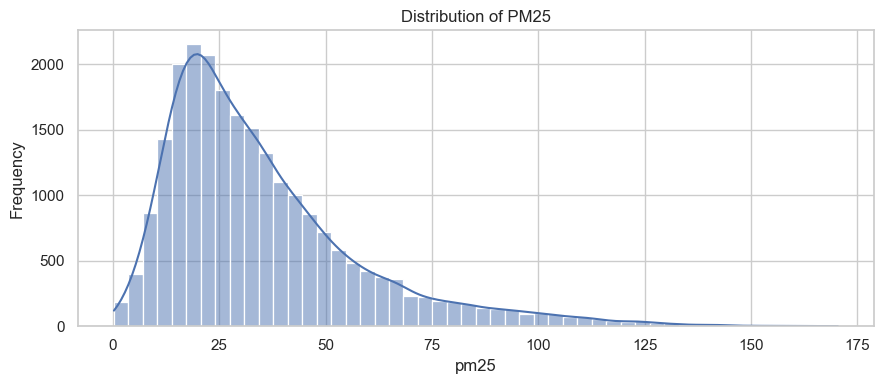

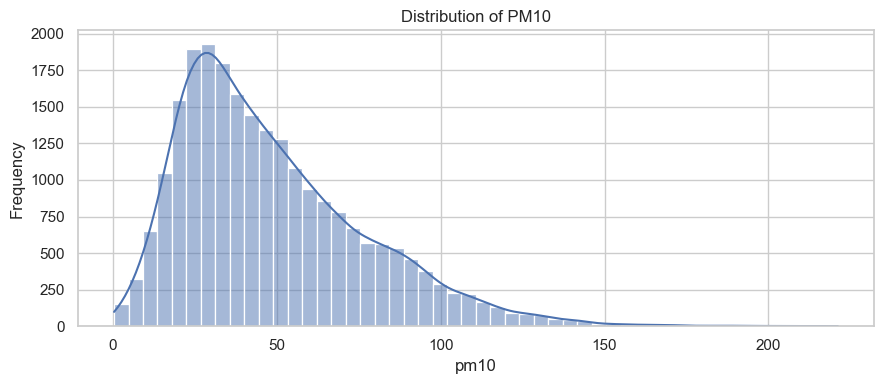

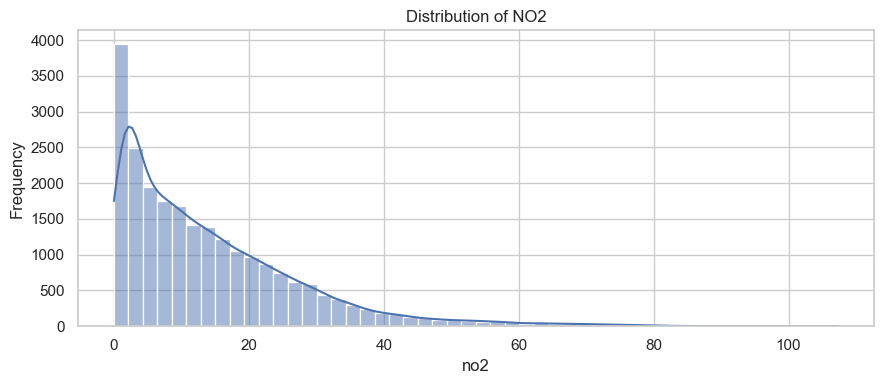

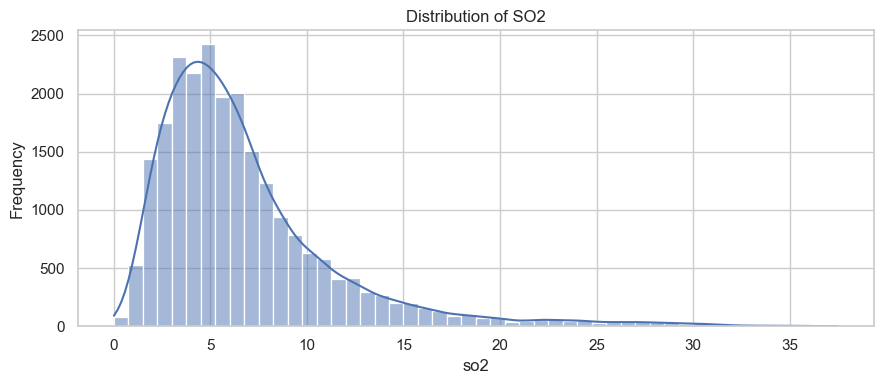

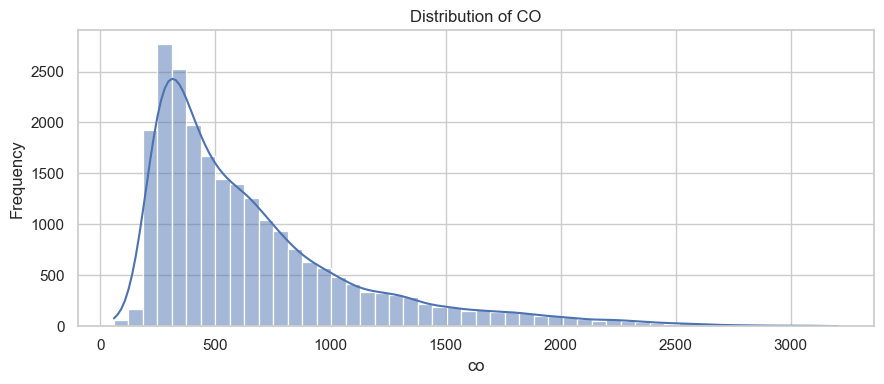

In [12]:
#pollutant distribution
for pollutant in pollutants:

    fig, ax = plt.subplots(figsize=(9, 4))

    sns.histplot(
        data=hourly,
        x=pollutant,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.set_title(
        f'Distribution of {pollutant.upper()}'
    )

    ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

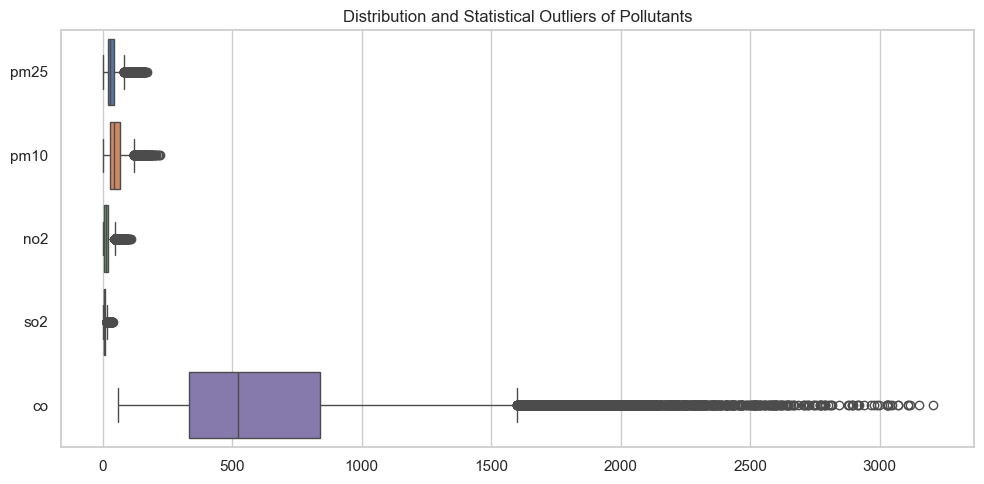

In [13]:
#Boxplots
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=hourly[pollutants],
    orient='h',
    ax=ax
)

ax.set_title(
    'Distribution and Statistical Outliers of Pollutants'
)

plt.tight_layout()
plt.show()

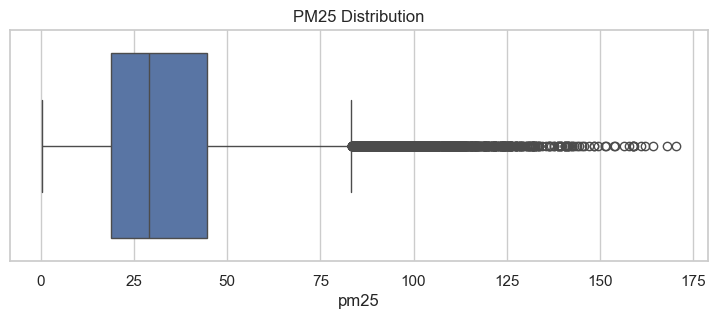

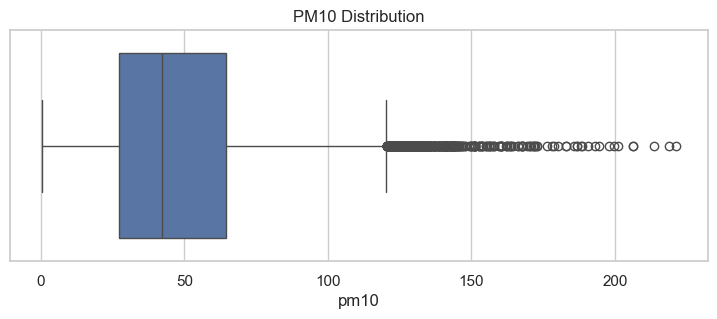

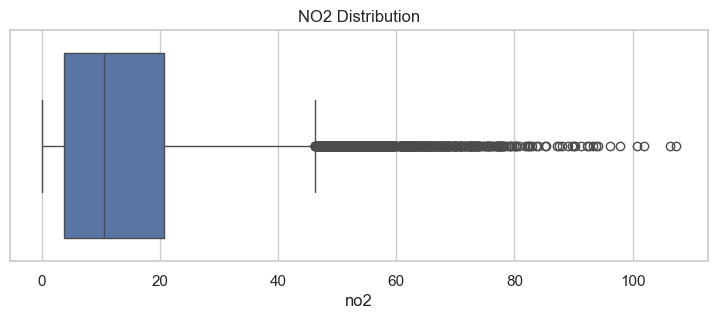

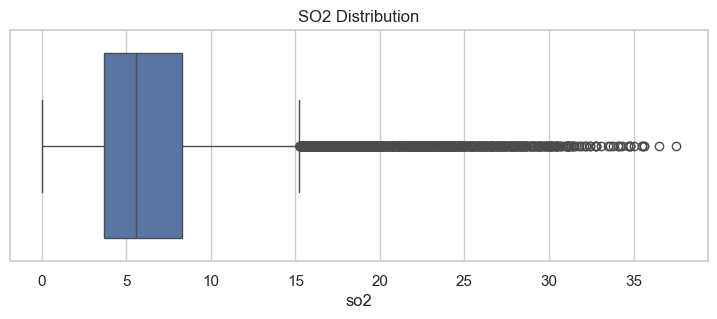

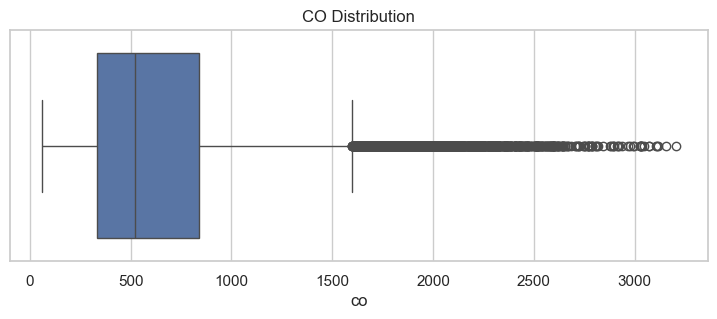

In [14]:
for pollutant in pollutants:

    plt.figure(figsize=(9, 3))

    sns.boxplot(
        x=hourly[pollutant]
    )

    plt.title(
        f'{pollutant.upper()} Distribution'
    )

    plt.show()

## Overall PM2.5 trend

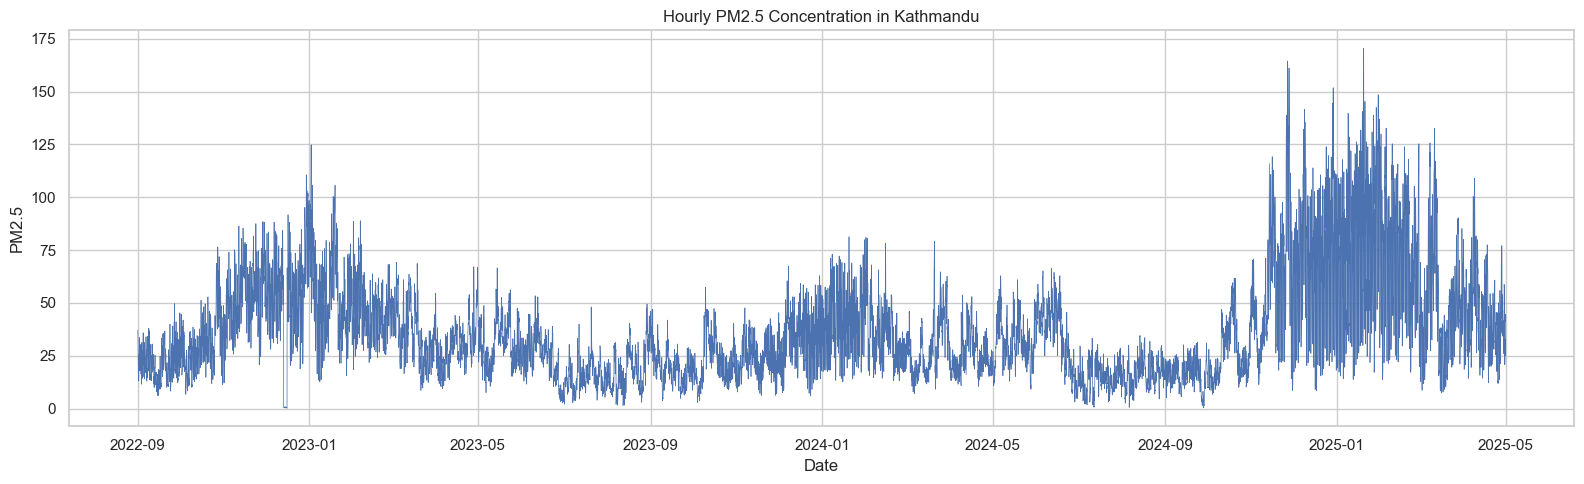

In [15]:
plt.figure(figsize=(16, 5))

plt.plot(
    hourly.index,
    hourly['pm25'],
    linewidth=0.5
)

plt.title(
    'Hourly PM2.5 Concentration in Kathmandu'
)

plt.xlabel('Date')
plt.ylabel('PM2.5')

plt.tight_layout()
plt.show()

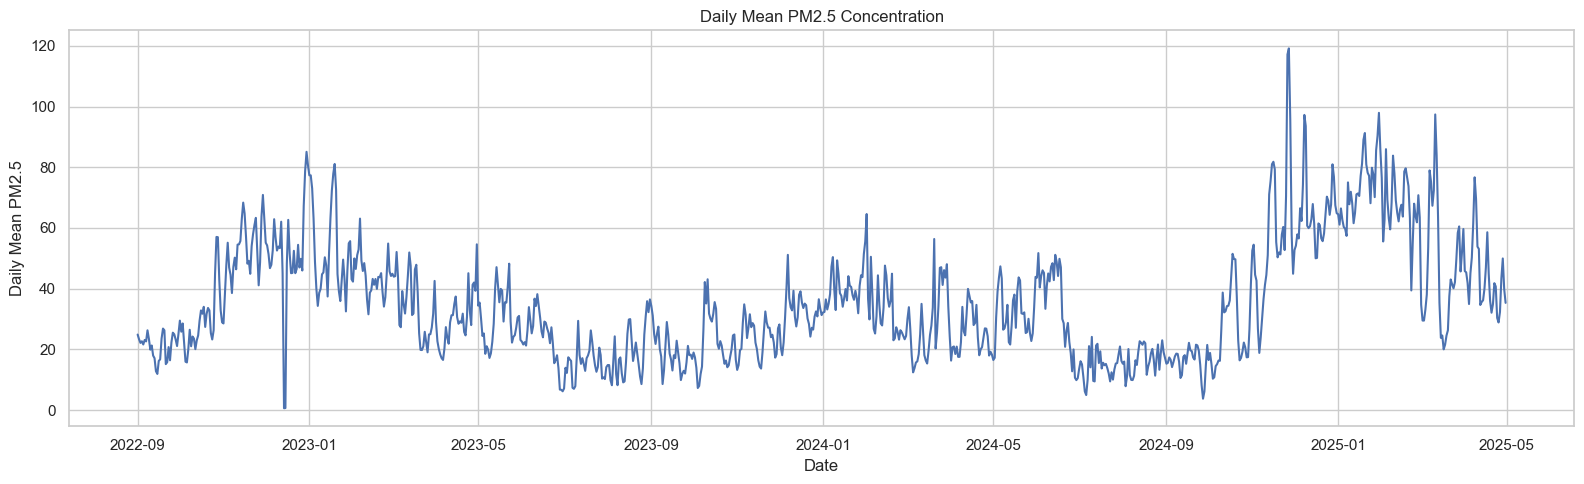

In [16]:
#Daily PM2.5 trend
plt.figure(figsize=(16, 5))

plt.plot(
    daily.index,
    daily['pm25_mean']
)

plt.title(
    'Daily Mean PM2.5 Concentration'
)

plt.xlabel('Date')
plt.ylabel('Daily Mean PM2.5')

plt.tight_layout()
plt.show()

In [17]:
#7-day and 30-day rolling means
daily['pm25_7d_mean'] = (
    daily['pm25_mean']
    .rolling(7)
    .mean()
)

daily['pm25_30d_mean'] = (
    daily['pm25_mean']
    .rolling(30)
    .mean()
)

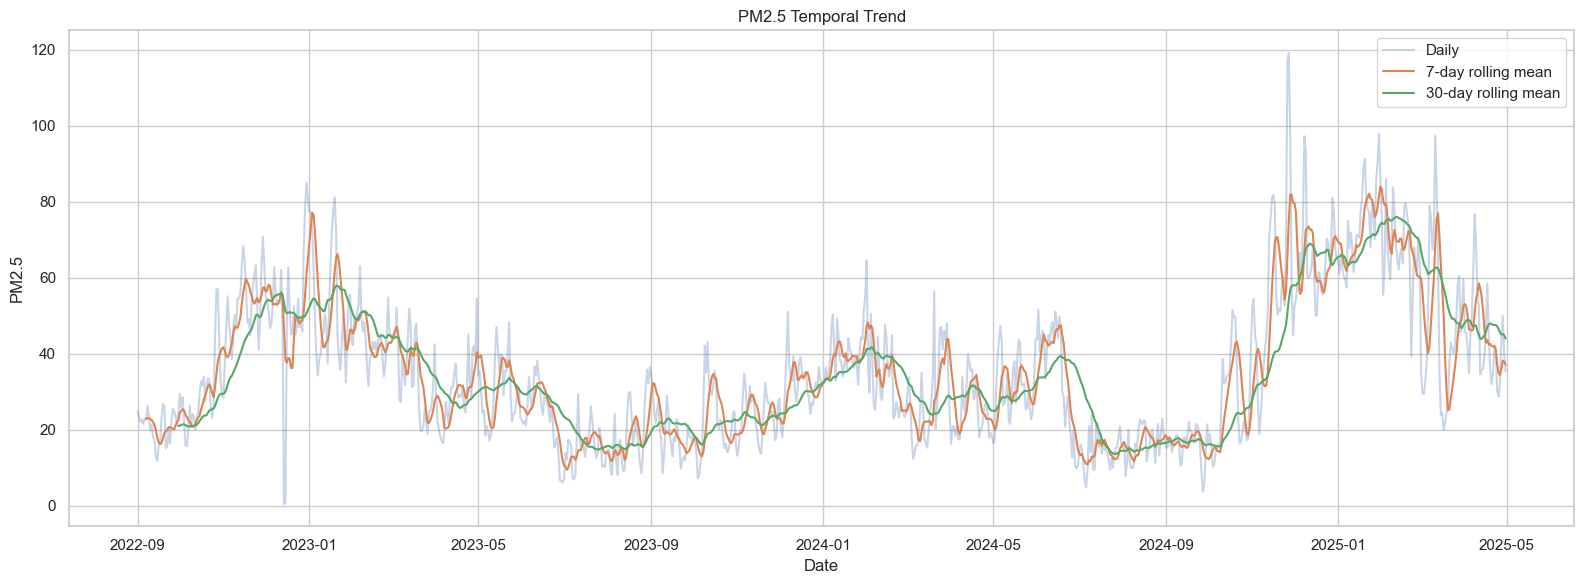

In [18]:
plt.figure(figsize=(16, 6))

plt.plot(
    daily.index,
    daily['pm25_mean'],
    alpha=0.3,
    label='Daily'
)

plt.plot(
    daily.index,
    daily['pm25_7d_mean'],
    label='7-day rolling mean'
)

plt.plot(
    daily.index,
    daily['pm25_30d_mean'],
    label='30-day rolling mean'
)

plt.title(
    'PM2.5 Temporal Trend'
)

plt.xlabel('Date')
plt.ylabel('PM2.5')

plt.legend()
plt.tight_layout()
plt.show()

## AQI analysis

In [19]:
daily['particle_aqi'].describe()

count    973.000000
mean     100.149024
std       35.509539
min        3.000000
25%       71.000000
50%       91.000000
75%      126.000000
max      196.000000
Name: particle_aqi, dtype: float64

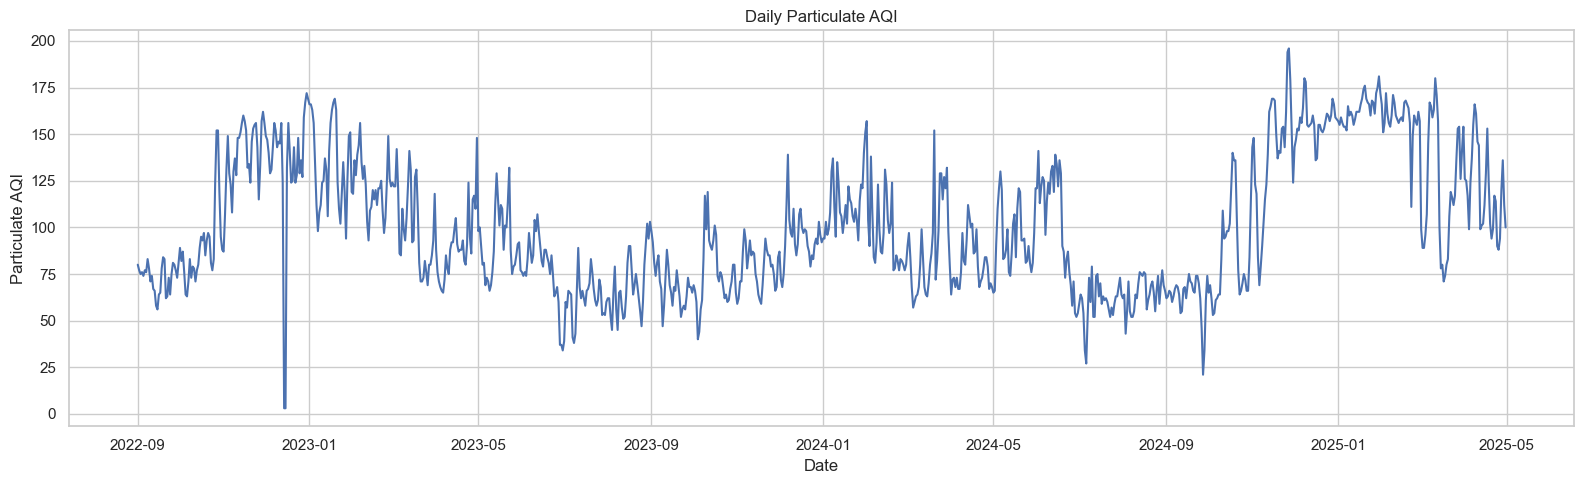

In [20]:
#aqi trend
plt.figure(figsize=(16, 5))

plt.plot(
    daily.index,
    daily['particle_aqi']
)

plt.title(
    'Daily Particulate AQI'
)

plt.xlabel('Date')
plt.ylabel('Particulate AQI')

plt.tight_layout()
plt.show()

In [21]:
#aqi categorical counts
aqi_counts = (
    daily['particle_aqi_category']
    .value_counts()
    .reindex(aqi_order)
)

aqi_counts

particle_aqi_category
Good                               21
Moderate                          555
Unhealthy for Sensitive Groups    252
Unhealthy                         145
Very Unhealthy                      0
Hazardous                           0
Name: count, dtype: int64

In [22]:
aqi_percentages = (
    aqi_counts
    / len(daily)
    * 100
)

aqi_percentages.round(2)

particle_aqi_category
Good                               2.16
Moderate                          57.04
Unhealthy for Sensitive Groups    25.90
Unhealthy                         14.90
Very Unhealthy                     0.00
Hazardous                          0.00
Name: count, dtype: float64

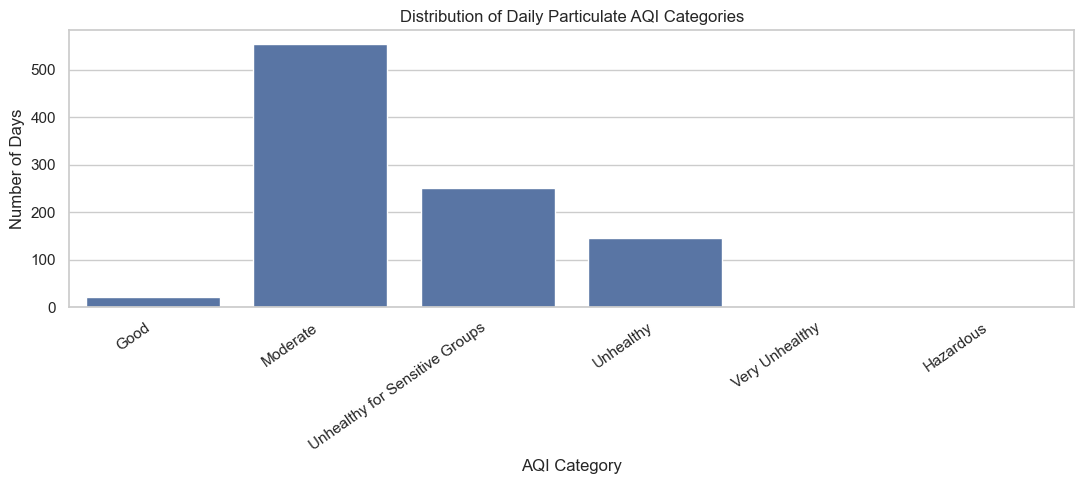

In [23]:
plt.figure(figsize=(11, 5))

sns.barplot(
    x=aqi_counts.index,
    y=aqi_counts.values
)

plt.xticks(
    rotation=35,
    ha='right'
)

plt.title(
    'Distribution of Daily Particulate AQI Categories'
)

plt.xlabel('AQI Category')
plt.ylabel('Number of Days')

plt.tight_layout()
plt.show()

## RQ1: Hourly patterns

In [24]:
hourly_pm25_pattern = (
    hourly
    .groupby('hour')['pm25']
    .agg([
        'mean',
        'median',
        'std',
        'count'
    ])
)

hourly_pm25_pattern

,mean,median,std,count
hour,,,,
0,43.534430,36.0,28.556127,973
1,41.454368,34.0,27.519761,973
2,39.498767,32.4,26.412615,973
3,37.707605,30.9,25.274461,973
4,36.138232,29.7,24.142018,973
5,35.758171,29.3,24.016966,973
6,38.218294,32.0,24.333896,973
7,40.478006,33.5,26.503810,973
8,37.139979,30.0,25.838245,973


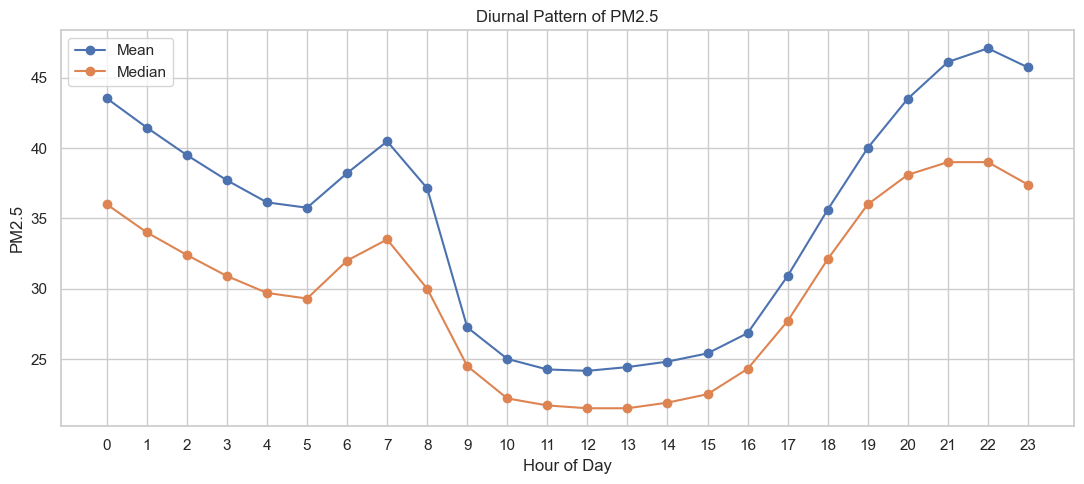

In [25]:
plt.figure(figsize=(11, 5))

plt.plot(
    hourly_pm25_pattern.index,
    hourly_pm25_pattern['mean'],
    marker='o',
    label='Mean'
)

plt.plot(
    hourly_pm25_pattern.index,
    hourly_pm25_pattern['median'],
    marker='o',
    label='Median'
)

plt.xticks(range(24))

plt.title(
    'Diurnal Pattern of PM2.5'
)

plt.xlabel('Hour of Day')
plt.ylabel('PM2.5')

plt.legend()
plt.tight_layout()
plt.show()

In [26]:
#All pollutants by hour
hourly_pollutant_pattern = (
    hourly
    .groupby('hour')[pollutants]
    .median()
)

hourly_pollutant_pattern

,pm25,pm10,no2,so2,co
hour,,,,,
0,36.0,51.7,22.6,7.3,818.0
1,34.0,48.8,18.6,6.9,743.0
2,32.4,46.6,15.8,6.8,672.0
3,30.9,44.6,14.0,6.7,643.0
4,29.7,42.8,13.1,6.5,626.0
5,29.3,42.3,13.1,6.3,631.0
6,32.0,46.2,11.9,6.3,599.0
7,33.5,48.9,9.3,6.3,522.0
8,30.0,45.2,6.4,6.1,442.0


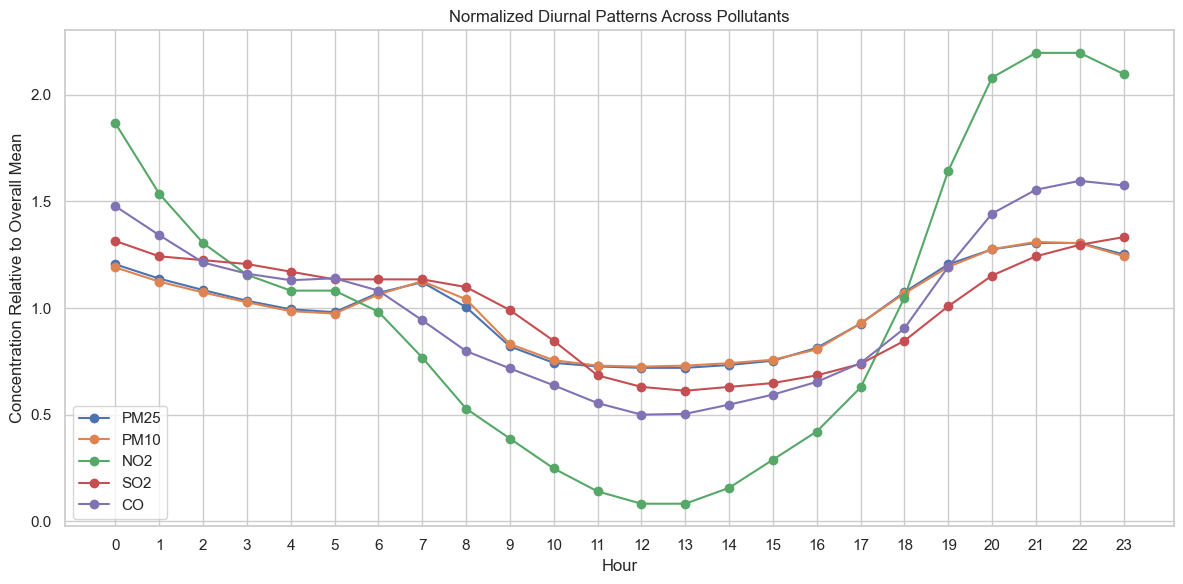

In [27]:
normalized_hourly = (
    hourly_pollutant_pattern
    / hourly_pollutant_pattern.mean()
)

plt.figure(figsize=(12, 6))

for pollutant in pollutants:

    plt.plot(
        normalized_hourly.index,
        normalized_hourly[pollutant],
        marker='o',
        label=pollutant.upper()
    )

plt.xticks(range(24))

plt.title(
    'Normalized Diurnal Patterns Across Pollutants'
)

plt.xlabel('Hour')
plt.ylabel(
    'Concentration Relative to Overall Mean'
)

plt.legend()
plt.tight_layout()
plt.show()

## Day-of-week and weekend patterns

In [28]:
dow_pm25 = (
    hourly
    .groupby('day_name', observed=False)['pm25']
    .agg([
        'mean',
        'median'
    ])
    .reindex(day_order)
)

dow_pm25

,mean,median
day_name,,
Monday,35.790887,30.25
Tuesday,35.787590,29.30
Wednesday,35.235192,27.65
Thursday,34.865378,28.15
Friday,34.698112,29.00
Saturday,34.037500,29.70
Sunday,34.903297,29.10


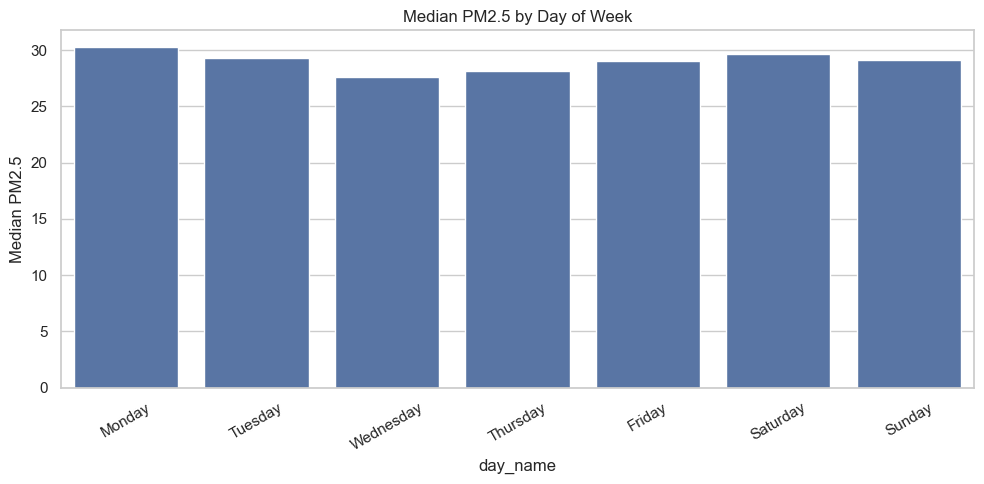

In [29]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=dow_pm25.index,
    y=dow_pm25['median']
)

plt.xticks(rotation=30)

plt.title(
    'Median PM2.5 by Day of Week'
)

plt.ylabel('Median PM2.5')

plt.tight_layout()
plt.show()

In [30]:
weekday_weekend = (
    hourly
    .groupby('day_type')['pm25']
    .agg([
        'count',
        'mean',
        'median',
        'std'
    ])
)

weekday_weekend

,count,mean,median,std
day_type,,,,
Weekday,16680,35.275432,28.9,23.551297
Weekend,6672,34.470399,29.3,22.478715


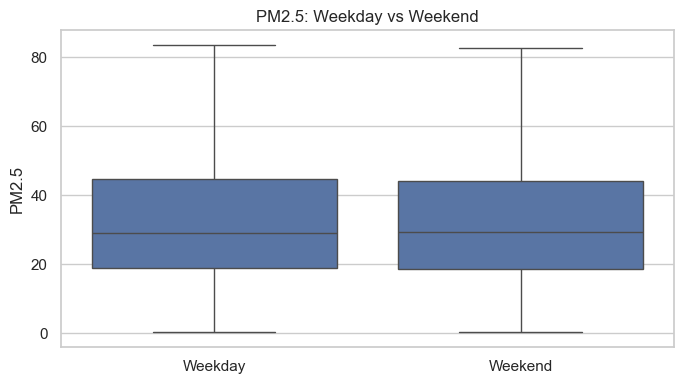

In [31]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=hourly,
    x='day_type',
    y='pm25',
    showfliers=False
)

plt.title(
    'PM2.5: Weekday vs Weekend'
)

plt.xlabel('')
plt.ylabel('PM2.5')

plt.tight_layout()
plt.show()

In [32]:
#Monthly patterns
monthly_pm25 = (
    hourly
    .groupby('month')['pm25']
    .agg([
        'mean',
        'median',
        'std',
        'count'
    ])
)

monthly_pm25

,mean,median,std,count
month,,,,
1,55.348387,48.20,29.158043,2232
2,48.158775,41.60,24.775296,2040
3,36.875762,33.25,20.444201,2232
4,32.946806,29.50,15.628317,2160
5,30.987298,30.00,10.707495,1488
6,29.503264,28.80,13.912088,1440
7,14.953024,14.40,6.894502,1488
8,17.642540,16.60,8.540674,1488
9,18.784444,18.30,7.428909,2160


In [33]:
month_labels = [
    'Jan', 'Feb', 'Mar', 'Apr',
    'May', 'Jun', 'Jul', 'Aug',
    'Sep', 'Oct', 'Nov', 'Dec'
]

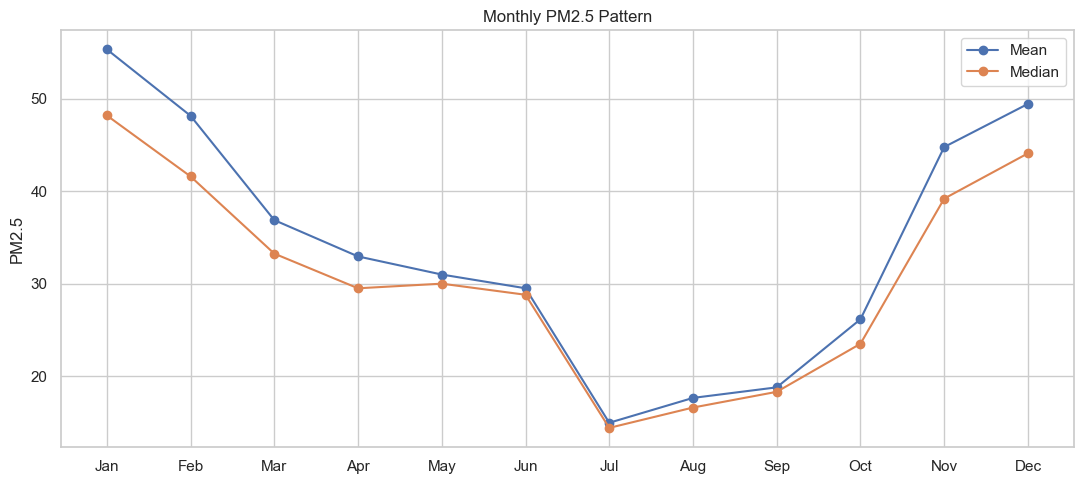

In [34]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_pm25.index,
    monthly_pm25['mean'],
    marker='o',
    label='Mean'
)

plt.plot(
    monthly_pm25.index,
    monthly_pm25['median'],
    marker='o',
    label='Median'
)

plt.xticks(
    range(1, 13),
    month_labels
)

plt.title(
    'Monthly PM2.5 Pattern'
)

plt.ylabel('PM2.5')

plt.legend()
plt.tight_layout()
plt.show()

## Seasonal patterns

In [35]:
season_pm25 = (
    hourly
    .groupby(
        'season',
        observed=False
    )['pm25']
    .agg([
        'count',
        'mean',
        'median',
        'std'
    ])
)

season_pm25

,count,mean,median,std
season,,,,
Winter,6504,51.067743,44.7,27.369442
Pre-Monsoon,5880,33.942330,31.0,16.827017
Monsoon,6576,20.006280,18.2,10.724533
Post-Monsoon,4392,35.312819,29.6,22.222706


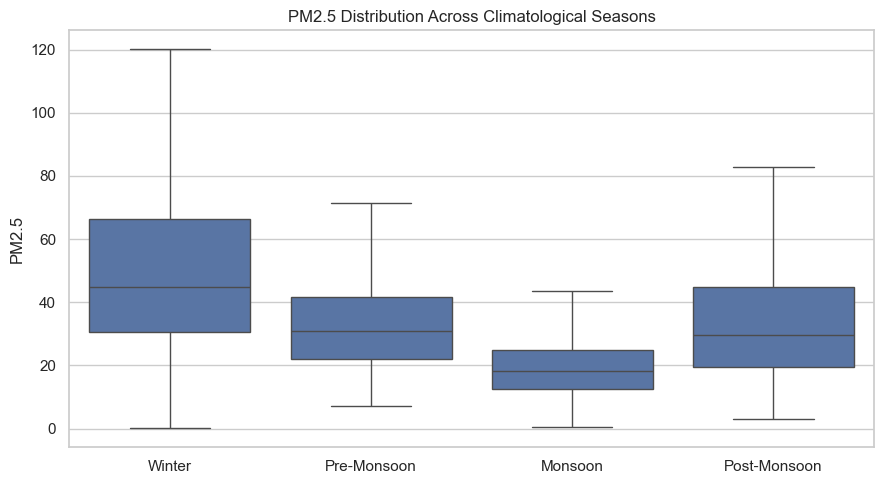

In [36]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=hourly,
    x='season',
    y='pm25',
    order=season_order,
    showfliers=False
)

plt.title(
    'PM2.5 Distribution Across Climatological Seasons'
)

plt.xlabel('')
plt.ylabel('PM2.5')

plt.tight_layout()
plt.show()

In [37]:
season_pollutants = (
    hourly
    .groupby(
        'season',
        observed=False
    )[pollutants]
    .median()
)

season_pollutants

,pm25,pm10,no2,so2,co
season,,,,,
Winter,44.7,62.05,17.1,9.4,948.0
Pre-Monsoon,31.0,46.30,7.4,5.1,451.0
Monsoon,18.2,26.30,8.0,4.0,355.0
Post-Monsoon,29.6,43.60,13.0,5.8,630.0


## Annual patterns

In [38]:
year_coverage = (
    hourly
    .groupby('year')
    .size()
)

year_coverage

year
2022    2928
2023    8760
2024    8784
2025    2880
dtype: int64

In [39]:
daily_coverage = (
    daily
    .groupby('year')
    .size()
)

daily_coverage

year
2022    122
2023    365
2024    366
2025    120
dtype: int64

In [40]:
#Annual descriptive PM2.5
annual_pm25 = (
    daily
    .groupby('year')['pm25_mean']
    .agg([
        'count',
        'mean',
        'median',
        'std'
    ])
)

annual_pm25

,count,mean,median,std
year,,,,
2022,122,38.722883,38.285417,17.749163
2023,365,28.823390,27.254167,13.461726
2024,366,32.500956,27.039583,18.665468
2025,120,57.992639,61.577083,18.711722


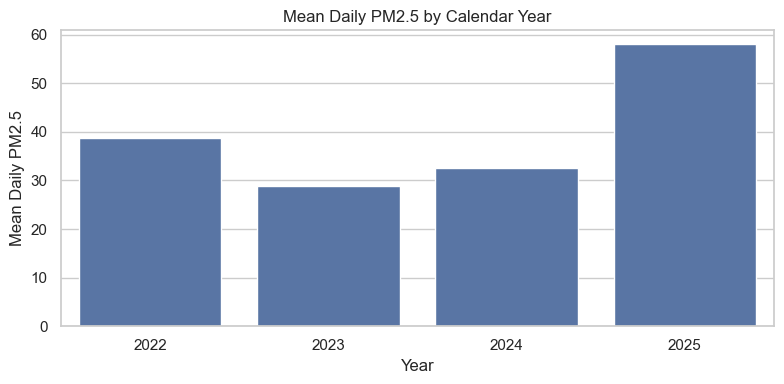

In [41]:
plt.figure(figsize=(8, 4))

sns.barplot(
    x=annual_pm25.index,
    y=annual_pm25['mean']
)

plt.title(
    'Mean Daily PM2.5 by Calendar Year'
)

plt.xlabel('Year')
plt.ylabel('Mean Daily PM2.5')

plt.tight_layout()
plt.show()

The 2022 and 2025 values represent partial years and should not be interpreted as directly comparable annual estimates.

## Temporal heatmaps

In [42]:
#Hour × day-of-week
hour_day_heatmap = hourly.pivot_table(
    values='pm25',
    index='day_name',
    columns='hour',
    aggfunc='median'
).reindex(day_order)

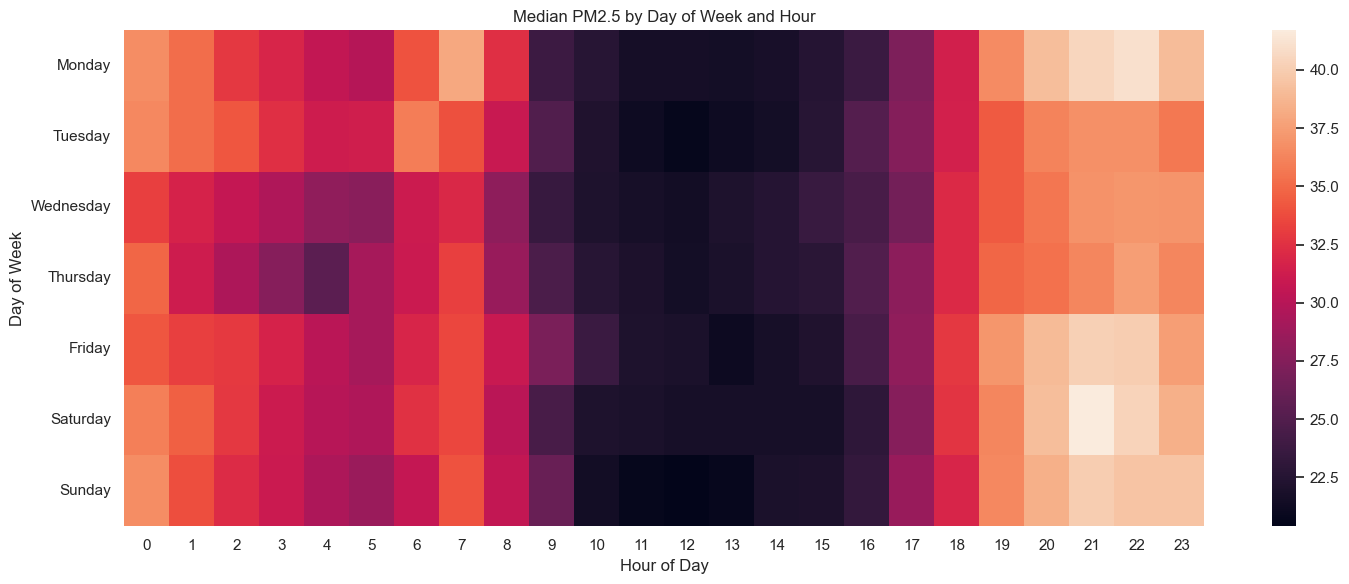

In [43]:
plt.figure(figsize=(15, 6))

sns.heatmap(
    hour_day_heatmap
)

plt.title(
    'Median PM2.5 by Day of Week and Hour'
)

plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.tight_layout()
plt.show()

In [44]:
#Hour × season
season_hour_heatmap = hourly.pivot_table(
    values='pm25',
    index='season',
    columns='hour',
    aggfunc='median',
    observed=False
).reindex(season_order)

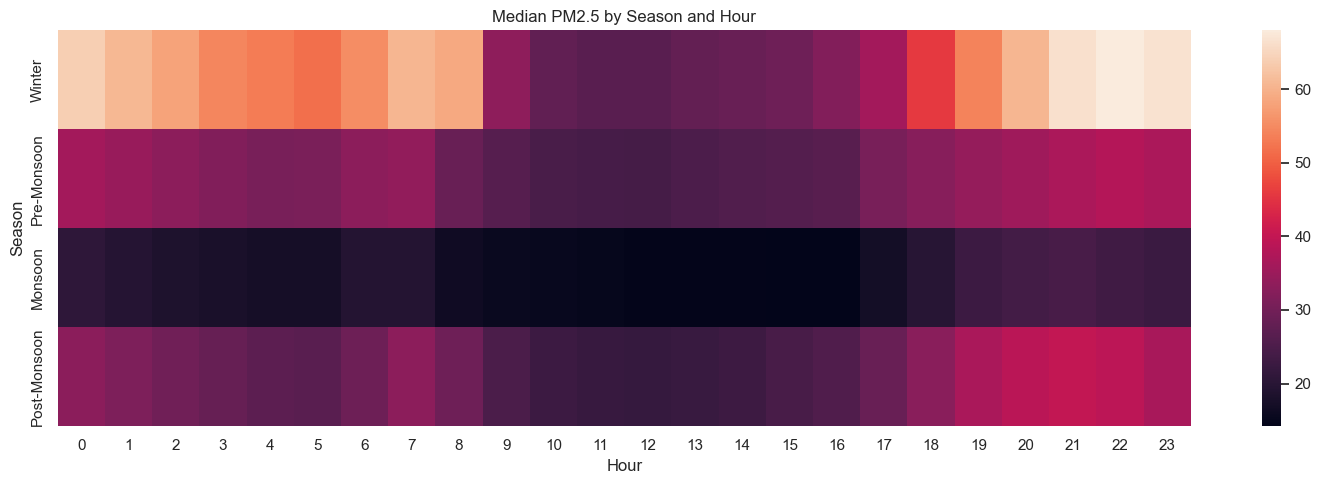

In [45]:
plt.figure(figsize=(15, 5))

sns.heatmap(
    season_hour_heatmap
)

plt.title(
    'Median PM2.5 by Season and Hour'
)

plt.xlabel('Hour')
plt.ylabel('Season')

plt.tight_layout()
plt.show()

In [46]:
#Month × hour
month_hour_heatmap = hourly.pivot_table(
    values='pm25',
    index='month',
    columns='hour',
    aggfunc='median'
)

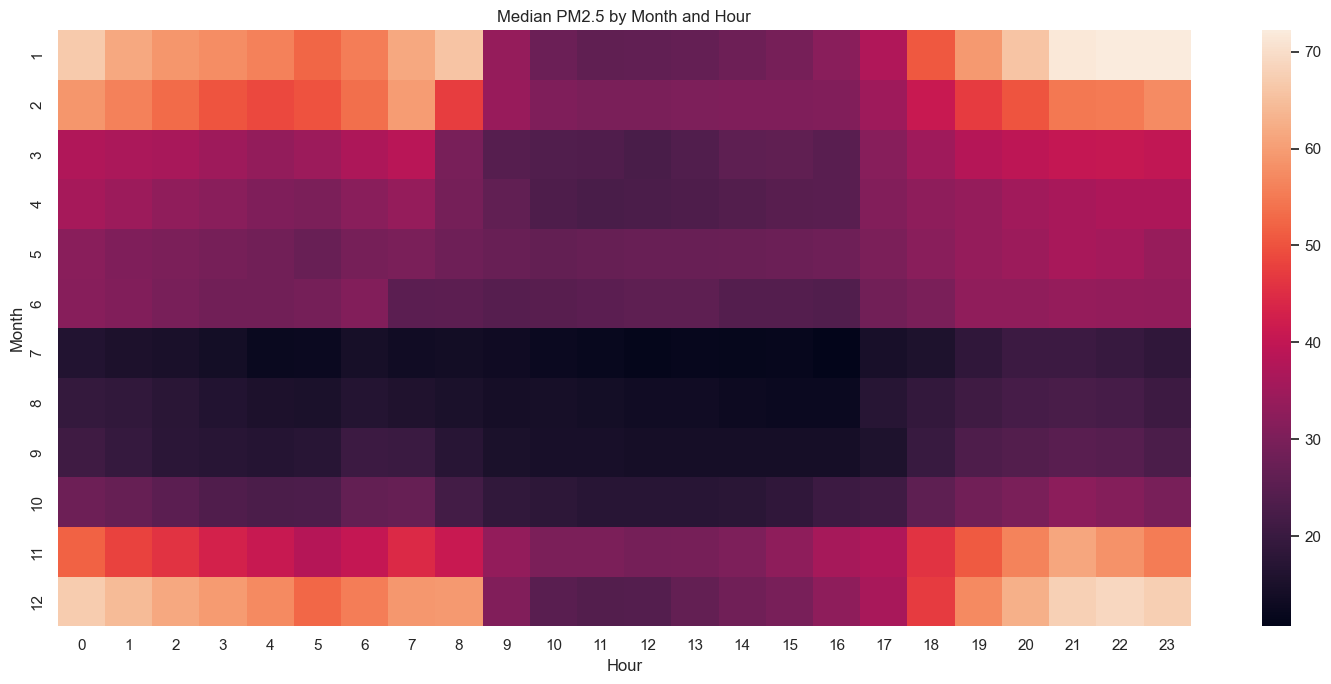

In [47]:
plt.figure(figsize=(15, 7))

sns.heatmap(
    month_hour_heatmap
)

plt.title(
    'Median PM2.5 by Month and Hour'
)

plt.xlabel('Hour')
plt.ylabel('Month')

plt.tight_layout()
plt.show()

In [48]:
#AQI temporal patterns
aqi_season_table = pd.crosstab(
    daily['season'],
    daily['particle_aqi_category'],
    normalize='index'
) * 100

In [49]:
aqi_season_table = (
    aqi_season_table
    .reindex(index=season_order)
    .reindex(columns=aqi_order)
)

aqi_season_table.round(1)

particle_aqi_category,Good,Moderate,Unhealthy for Sensitive Groups,Unhealthy,Very Unhealthy,Hazardous
season,,,,,,
Winter,0.7,19.9,40.6,38.7,NaN,NaN
Pre-Monsoon,0.0,62.9,31.0,6.1,NaN,NaN
Monsoon,6.2,86.1,7.7,0.0,NaN,NaN
Post-Monsoon,1.1,60.7,24.6,13.7,NaN,NaN


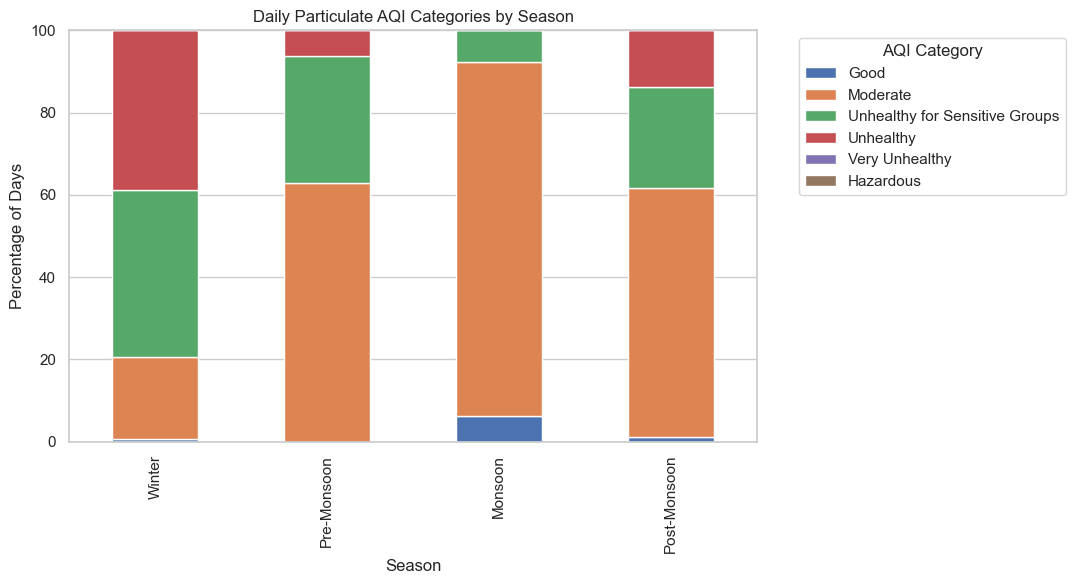

In [50]:
aqi_season_table.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6)
)

plt.title(
    'Daily Particulate AQI Categories by Season'
)

plt.xlabel('Season')
plt.ylabel('Percentage of Days')

plt.legend(
    title='AQI Category',
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

In [52]:
#Pollutant relationships
#Pearson correlation
pearson_pollutants = (
    hourly[pollutants]
    .corr(method='pearson')
)

pearson_pollutants.round(3)

,pm25,pm10,no2,so2,co
pm25,1.000,0.949,0.510,0.802,0.639
pm10,0.949,1.000,0.490,0.686,0.602
no2,0.510,0.490,1.000,0.476,0.779
so2,0.802,0.686,0.476,1.000,0.662
co,0.639,0.602,0.779,0.662,1.000


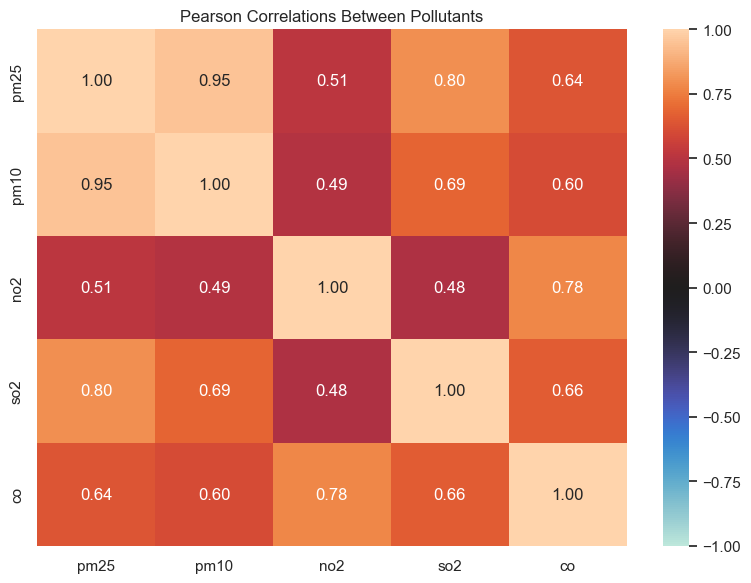

In [53]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    pearson_pollutants,
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title(
    'Pearson Correlations Between Pollutants'
)

plt.tight_layout()
plt.show()

In [54]:
#Spearman correlation
spearman_pollutants = (
    hourly[pollutants]
    .corr(method='spearman')
)

spearman_pollutants.round(3)

,pm25,pm10,no2,so2,co
pm25,1.000,0.979,0.487,0.729,0.677
pm10,0.979,1.000,0.445,0.680,0.628
no2,0.487,0.445,1.000,0.581,0.842
so2,0.729,0.680,0.581,1.000,0.772
co,0.677,0.628,0.842,0.772,1.000


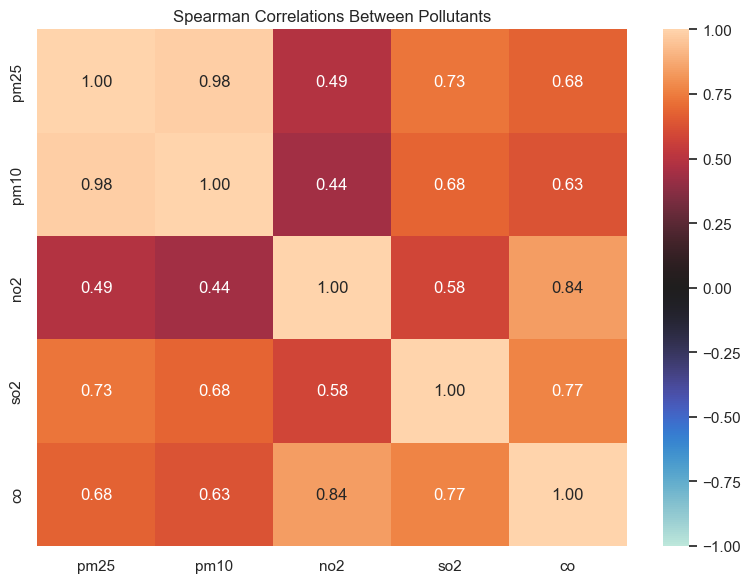

In [55]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    spearman_pollutants,
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title(
    'Spearman Correlations Between Pollutants'
)

plt.tight_layout()
plt.show()

In [56]:
#Pairplot
pairplot_sample = (
    hourly[pollutants]
    .sample(
        n=min(4000, len(hourly)),
        random_state=42
    )
)

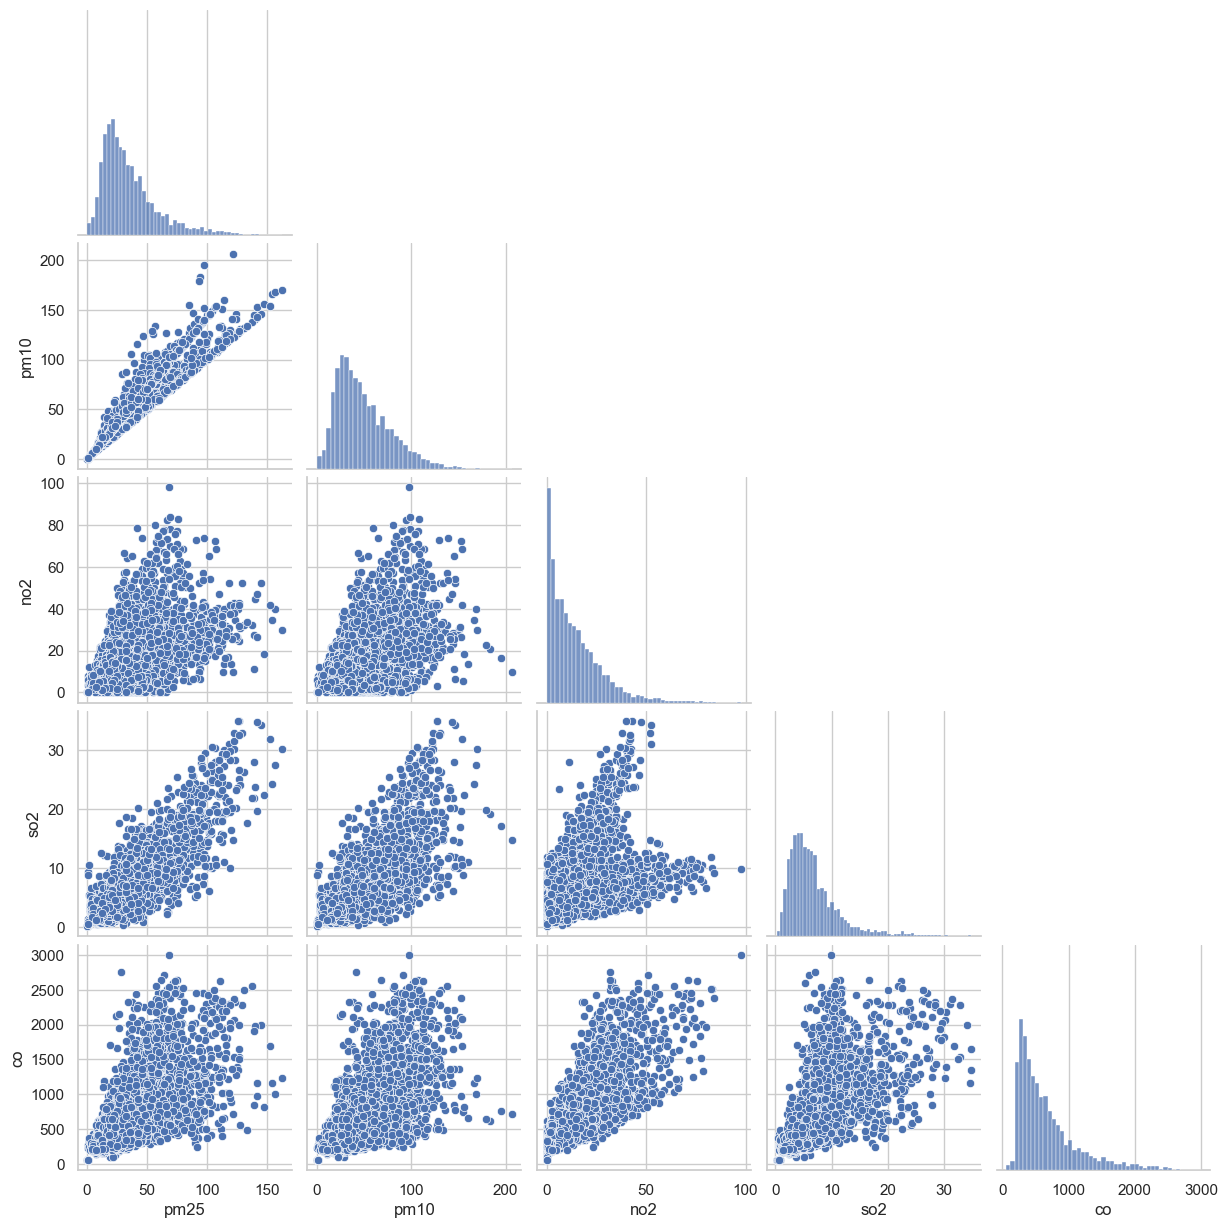

In [57]:
sns.pairplot(
    pairplot_sample,
    corner=True,
    diag_kind='hist'
)

plt.show()

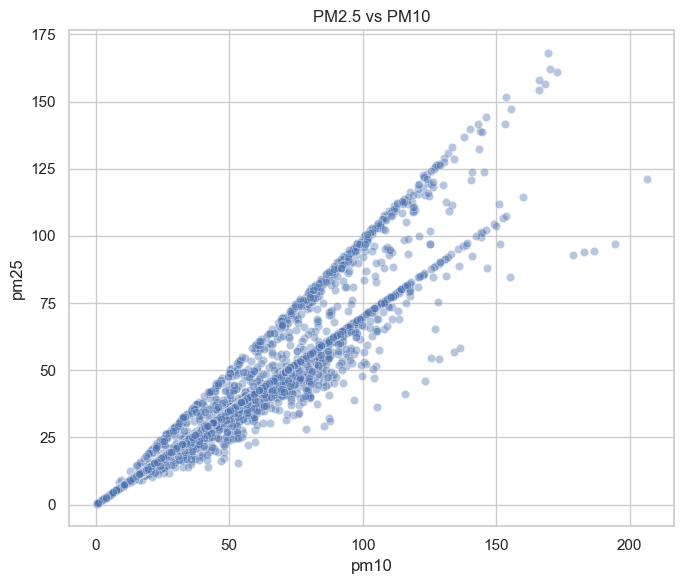

In [58]:
#PM2.5 and PM10 relationship
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=hourly.sample(
        min(5000, len(hourly)),
        random_state=42
    ),
    x='pm10',
    y='pm25',
    alpha=0.4
)

plt.title(
    'PM2.5 vs PM10'
)

plt.tight_layout()
plt.show()

In [59]:
hourly['pm25_pm10_ratio'].describe()

count    23352.000000
mean         0.708807
std          0.099759
min          0.257143
25%          0.679245
50%          0.697297
75%          0.701538
max          1.000000
Name: pm25_pm10_ratio, dtype: float64

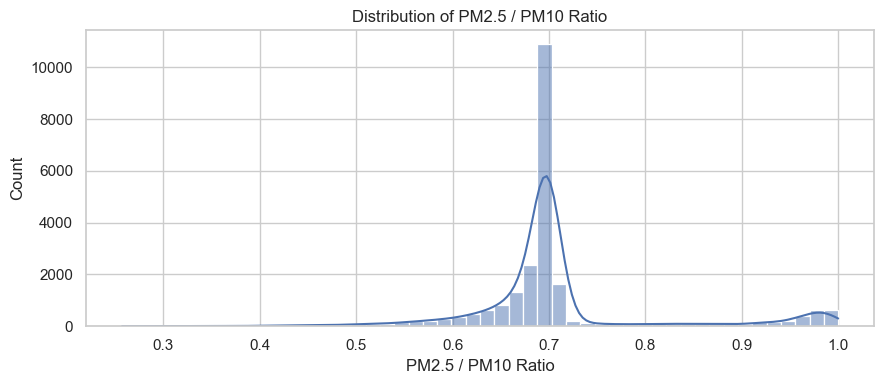

In [60]:
plt.figure(figsize=(9, 4))

sns.histplot(
    hourly['pm25_pm10_ratio'],
    bins=50,
    kde=True
)

plt.title(
    'Distribution of PM2.5 / PM10 Ratio'
)

plt.xlabel('PM2.5 / PM10 Ratio')

plt.tight_layout()
plt.show()

In [61]:
ratio_season = (
    hourly
    .groupby(
        'season',
        observed=False
    )['pm25_pm10_ratio']
    .median()
)

ratio_season

season
Winter          0.698909
Pre-Monsoon     0.685121
Monsoon         0.698795
Post-Monsoon    0.695652
Name: pm25_pm10_ratio, dtype: float64

In [62]:
#Combined pollution-weather correlations
correlation_variables = (
    pollutants
    + weather_variables
)

In [63]:
pearson_all = (
    hourly[correlation_variables]
    .corr(method='pearson')
)

In [64]:
spearman_all = (
    hourly[correlation_variables]
    .corr(method='spearman')
)

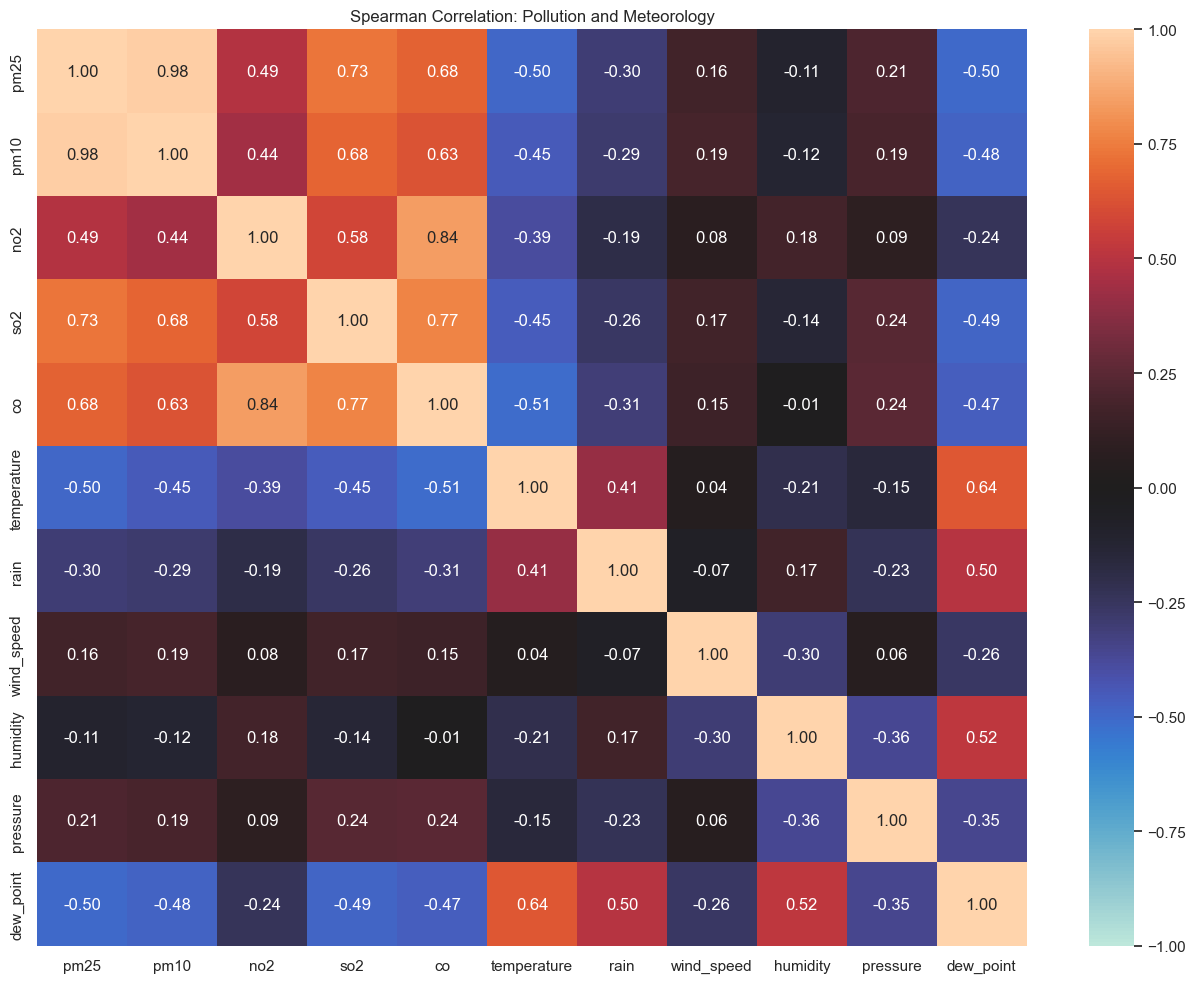

In [65]:
plt.figure(figsize=(13, 10))

sns.heatmap(
    spearman_all,
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title(
    'Spearman Correlation: Pollution and Meteorology'
)

plt.tight_layout()
plt.show()

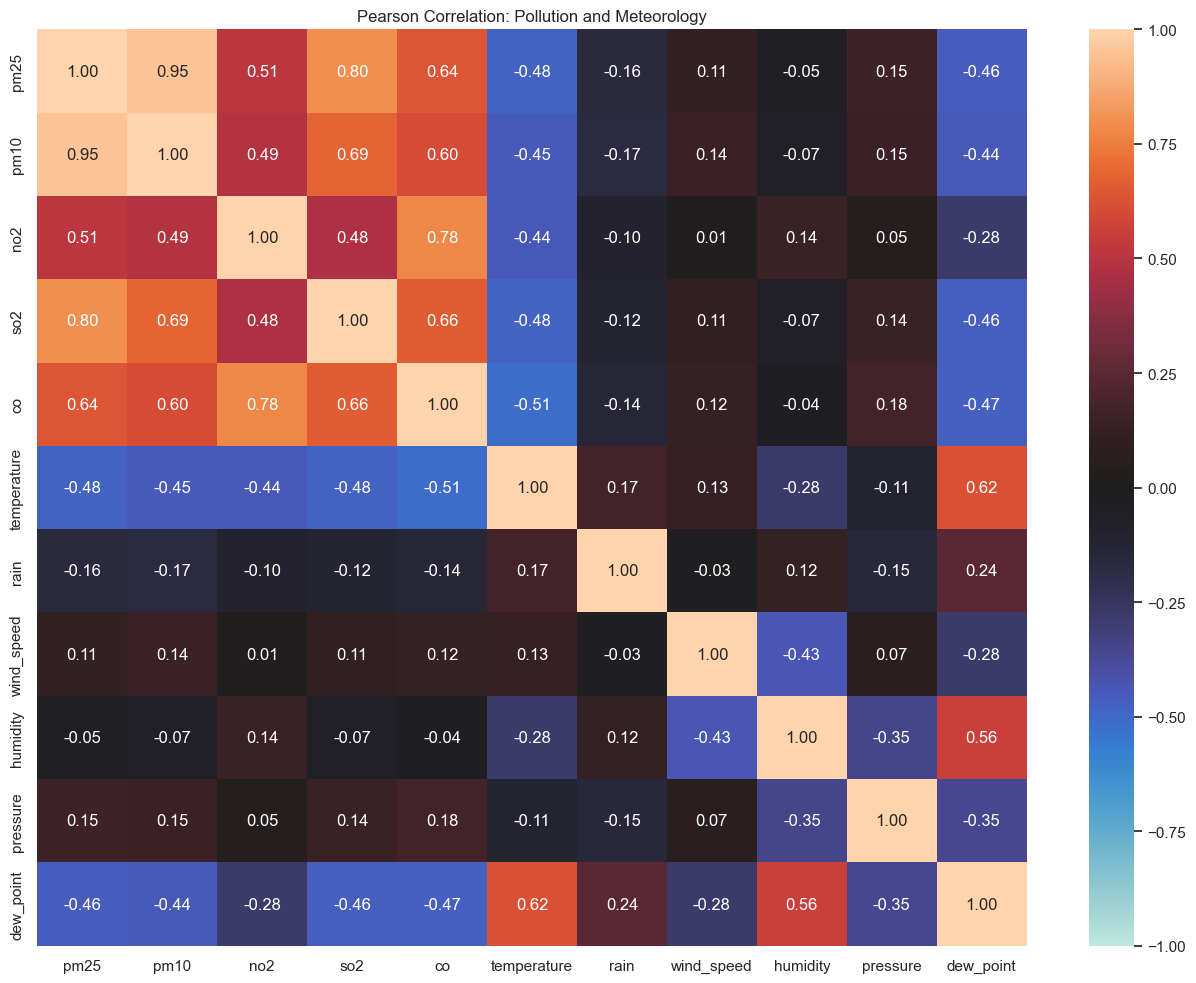

In [66]:
plt.figure(figsize=(13, 10))

sns.heatmap(
    pearson_all,
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title(
    'Pearson Correlation: Pollution and Meteorology'
)

plt.tight_layout()
plt.show()

In [67]:
#PM2.5 weather table
pm25_weather_correlations = pd.DataFrame({
    'Pearson': [
        hourly['pm25'].corr(
            hourly[var],
            method='pearson'
        )
        for var in weather_variables
    ],

    'Spearman': [
        hourly['pm25'].corr(
            hourly[var],
            method='spearman'
        )
        for var in weather_variables
    ]
}, index=weather_variables)

pm25_weather_correlations.sort_values(
    'Spearman'
).round(3)

,Pearson,Spearman
dew_point,-0.457,-0.503
temperature,-0.484,-0.496
rain,-0.158,-0.297
humidity,-0.054,-0.108
wind_speed,0.113,0.165
pressure,0.149,0.209


In [68]:
#PM2.5 vs individual meteorological variables
weather_sample = hourly.sample(
    min(6000, len(hourly)),
    random_state=42
)

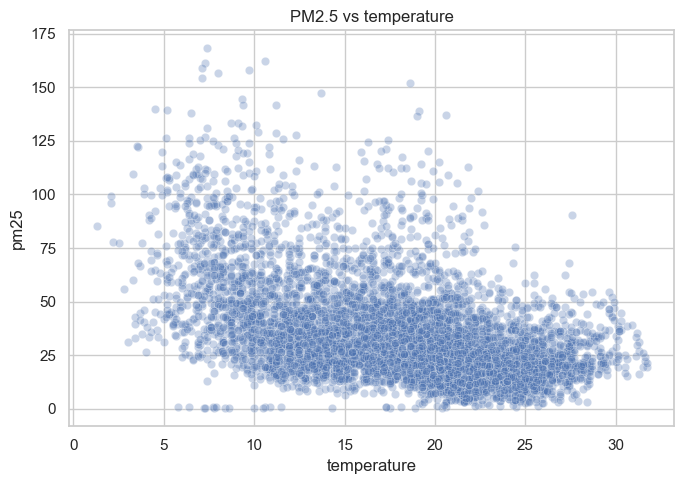

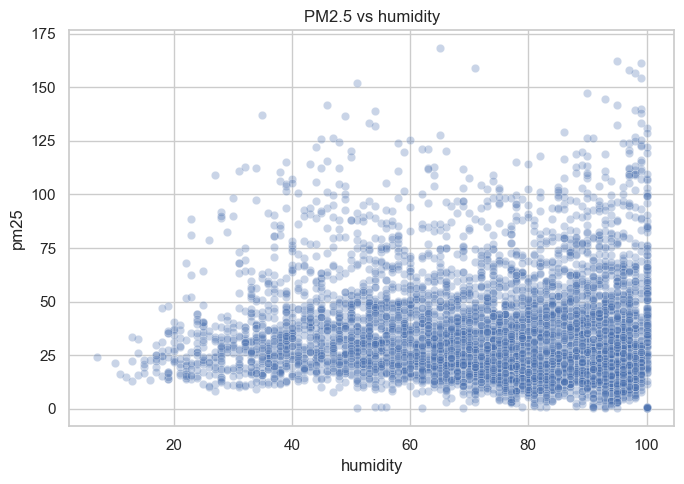

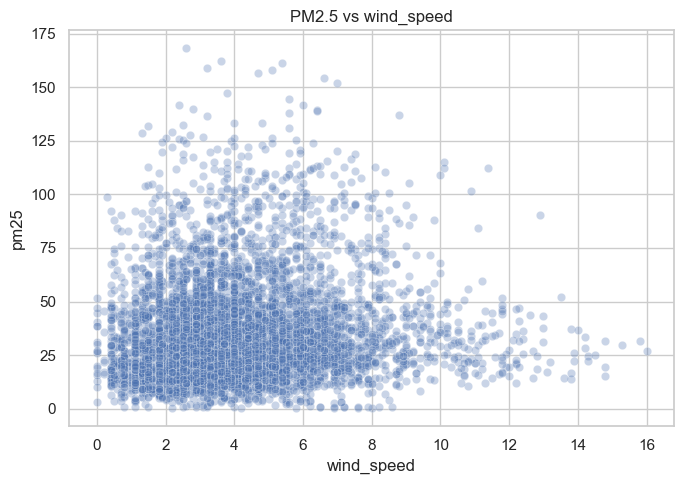

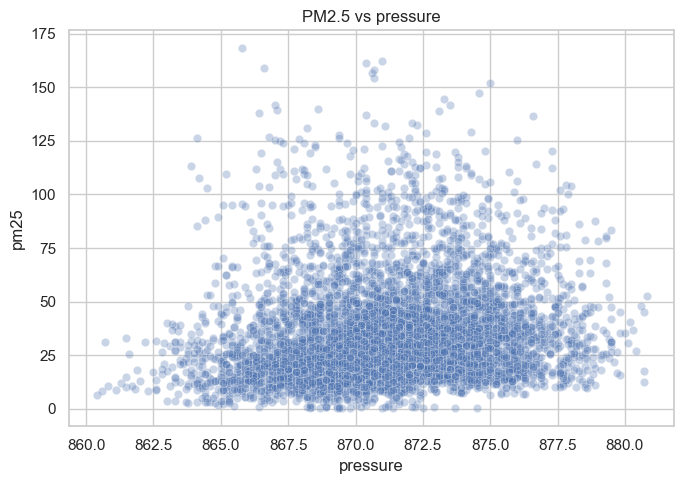

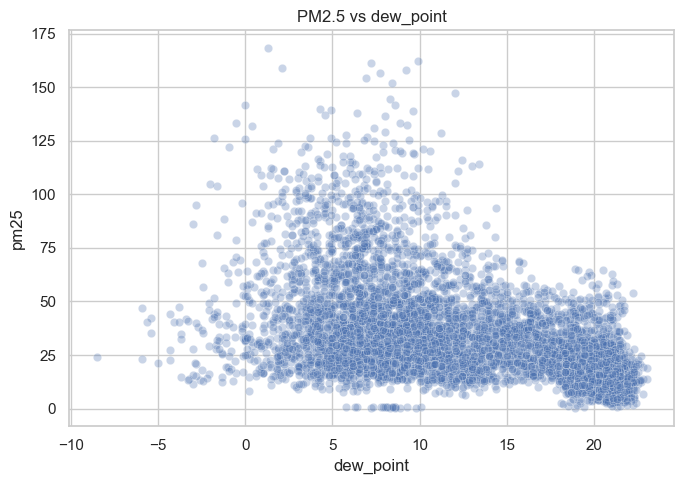

In [69]:
for variable in [
    'temperature',
    'humidity',
    'wind_speed',
    'pressure',
    'dew_point'
]:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=weather_sample,
        x=variable,
        y='pm25',
        alpha=0.3
    )

    plt.title(
        f'PM2.5 vs {variable}'
    )

    plt.tight_layout()
    plt.show()

In [70]:
#Wind analysis
wind_counts = (
    hourly['wind_sector']
    .value_counts()
    .reindex(wind_order)
)

wind_counts

wind_sector
N      2339
NE      973
E       809
SE     1894
S     11134
SW      810
W      1080
NW     4313
Name: count, dtype: int64

In [71]:
wind_pm25 = (
    hourly
    .groupby(
        'wind_sector',
        observed=False
    )['pm25']
    .agg([
        'count',
        'mean',
        'median',
        'std'
    ])
    .reindex(wind_order)
)

wind_pm25

,count,mean,median,std
wind_sector,,,,
N,2339,32.211714,25.10,23.117678
NE,973,28.598869,21.90,20.386105
E,809,28.394561,22.50,20.869508
SE,1894,27.184477,21.80,20.466189
S,11134,40.006763,33.80,24.722326
SW,810,27.373210,24.45,15.224075
W,1080,27.332407,24.60,15.213093
NW,4313,33.300626,28.30,21.396367


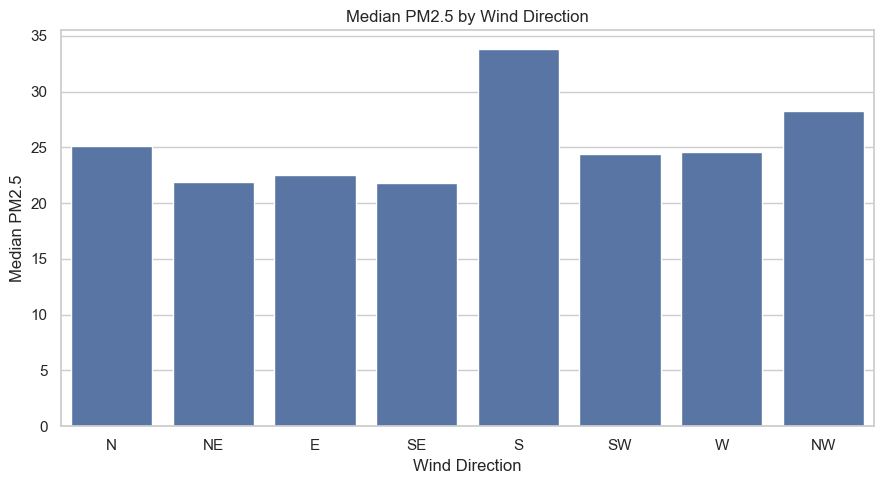

In [72]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=wind_pm25.index,
    y=wind_pm25['median']
)

plt.title(
    'Median PM2.5 by Wind Direction'
)

plt.xlabel('Wind Direction')
plt.ylabel('Median PM2.5')

plt.tight_layout()
plt.show()

In [73]:
wind_pollutants = (
    hourly
    .groupby(
        'wind_sector',
        observed=False
    )[pollutants]
    .median()
    .reindex(wind_order)
)

wind_pollutants

,pm25,pm10,no2,so2,co
wind_sector,,,,,
N,25.10,35.50,8.7,5.70,501.0
NE,21.90,32.40,9.3,4.90,459.0
E,22.50,33.40,8.7,4.90,424.0
SE,21.80,32.00,8.8,4.35,397.0
S,33.80,48.70,16.6,6.20,659.0
SW,24.45,35.30,2.1,4.20,334.0
W,24.60,38.15,3.5,4.50,345.0
NW,28.30,41.90,7.9,5.60,483.0


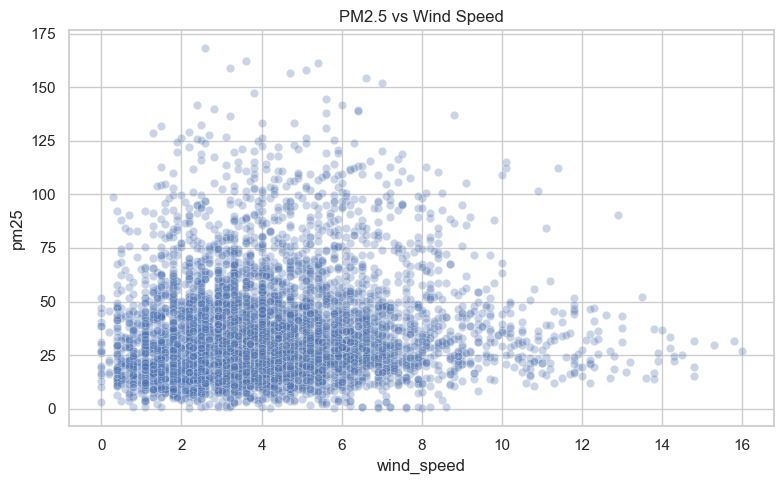

In [74]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=weather_sample,
    x='wind_speed',
    y='pm25',
    alpha=0.3
)

plt.title(
    'PM2.5 vs Wind Speed'
)

plt.tight_layout()
plt.show()

In [75]:
hourly['wind_speed_quartile'] = pd.qcut(
    hourly['wind_speed'],
    q=4,
    duplicates='drop'
)

In [76]:
wind_speed_groups = (
    hourly
    .groupby(
        'wind_speed_quartile',
        observed=False
    )['pm25']
    .agg([
        'count',
        'mean',
        'median'
    ])
)

wind_speed_groups

,count,mean,median
wind_speed_quartile,,,
"(-0.001, 2.5]",6532,30.390447,24.2
"(2.5, 3.7]",5379,34.525767,28.8
"(3.7, 5.3]",5611,36.654358,30.9
"(5.3, 18.8]",5830,39.191870,33.2


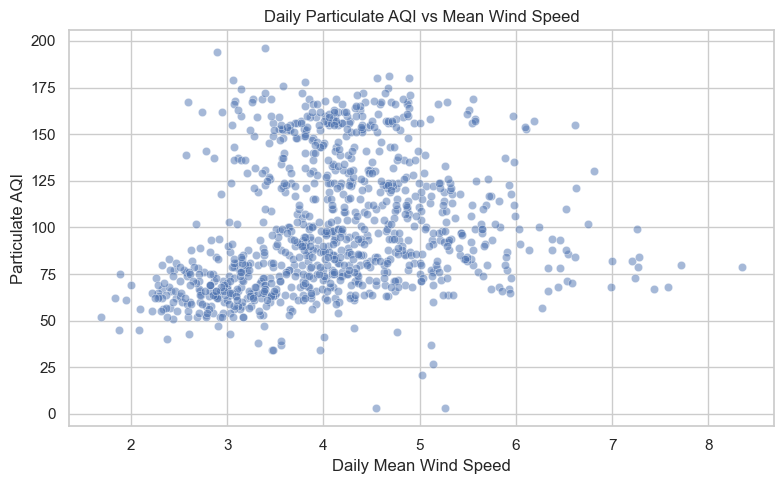

In [77]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=daily,
    x='wind_speed_mean',
    y='particle_aqi',
    alpha=0.5
)

plt.title(
    'Daily Particulate AQI vs Mean Wind Speed'
)

plt.xlabel('Daily Mean Wind Speed')
plt.ylabel('Particulate AQI')

plt.tight_layout()
plt.show()

In [78]:
#Rain analysis
hourly['rain_status'].value_counts()

rain_status
Dry     18325
Rain     5027
Name: count, dtype: int64

In [79]:
rain_pm25 = (
    hourly
    .groupby('rain_status')['pm25']
    .agg([
        'count',
        'mean',
        'median',
        'std'
    ])
)

rain_pm25

,count,mean,median,std
rain_status,,,,
Dry,18325,37.957364,31.9,23.709408
Rain,5027,24.430475,19.8,17.857464


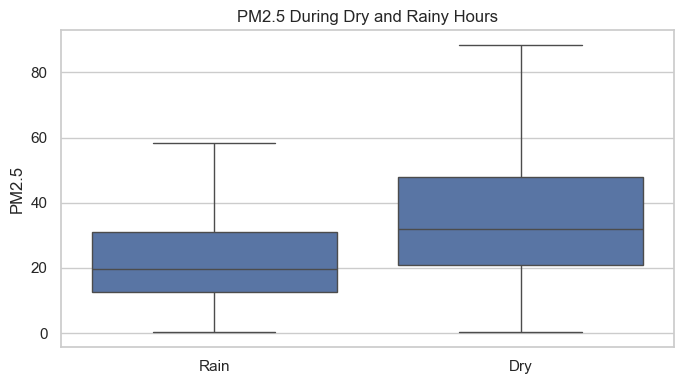

In [80]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=hourly,
    x='rain_status',
    y='pm25',
    showfliers=False
)

plt.title(
    'PM2.5 During Dry and Rainy Hours'
)

plt.xlabel('')
plt.ylabel('PM2.5')

plt.tight_layout()
plt.show()

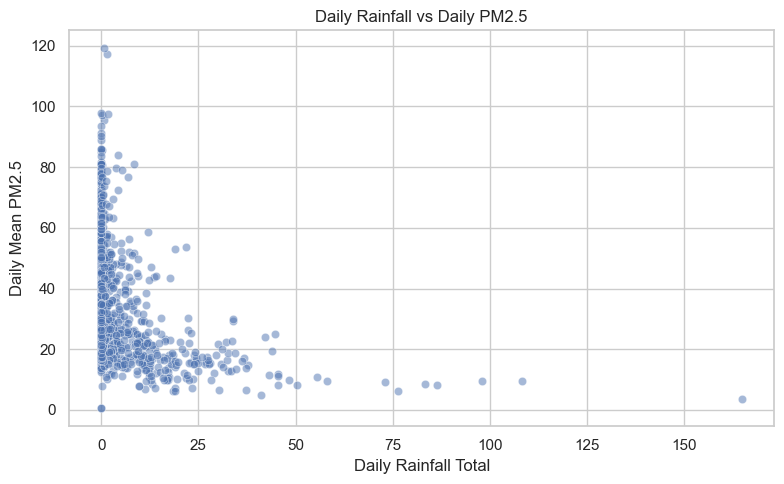

In [81]:
#Daily rainfall vs daily PM2.5
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=daily,
    x='rain_total',
    y='pm25_mean',
    alpha=0.5
)

plt.title(
    'Daily Rainfall vs Daily PM2.5'
)

plt.xlabel('Daily Rainfall Total')
plt.ylabel('Daily Mean PM2.5')

plt.tight_layout()
plt.show()

## Extreme PM2.5 exploratory analysis

In [82]:
print(
    "90th percentile threshold:",
    hourly['pm25'].quantile(0.90)
)

print(
    "95th percentile threshold:",
    hourly['pm25'].quantile(0.95)
)

print(
    "Top-10% flagged observations:",
    hourly['pm25_top10'].sum()
)

print(
    "Top-5% flagged observations:",
    hourly['pm25_top5'].sum()
)

90th percentile threshold: 66.1
95th percentile threshold: 83.6
Top-10% flagged observations: 2354
Top-5% flagged observations: 1177


In [83]:
#Extreme observations by month
extreme_month = (
    hourly
    .groupby('month')['pm25_top10']
    .mean()
    * 100
)

extreme_month

month
1     29.883513
2     19.950980
3      7.930108
4      4.768519
5      0.067204
6      0.069444
7      0.000000
8      0.000000
9      0.000000
10     0.672043
11    19.027778
12    25.627240
Name: pm25_top10, dtype: float64

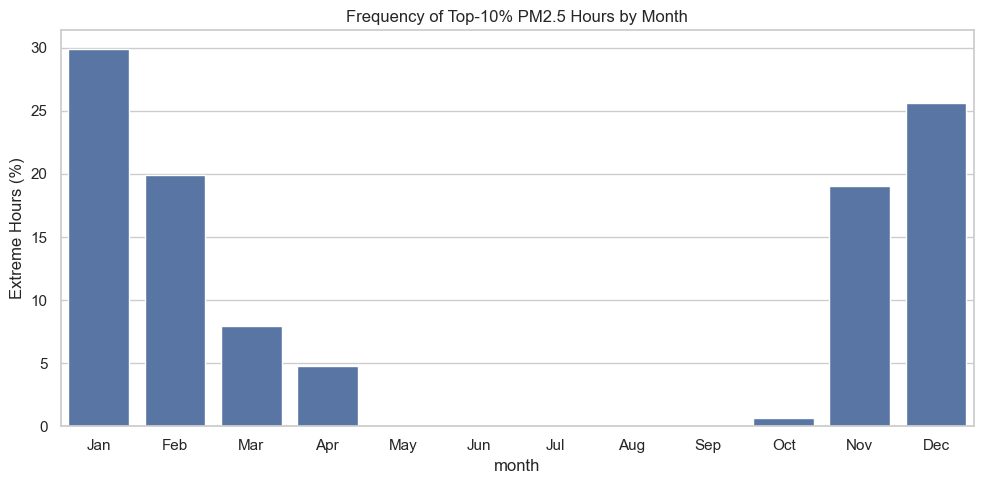

In [84]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=extreme_month.index,
    y=extreme_month.values
)

plt.xticks(
    range(12),
    month_labels
)

plt.title(
    'Frequency of Top-10% PM2.5 Hours by Month'
)

plt.ylabel(
    'Extreme Hours (%)'
)

plt.tight_layout()
plt.show()

In [85]:
#Extreme pollution by season
extreme_season = (
    hourly
    .groupby(
        'season',
        observed=False
    )['pm25_top10']
    .mean()
    * 100
)

extreme_season

season
Winter          25.307503
Pre-Monsoon      4.778912
Monsoon          0.015207
Post-Monsoon     9.699454
Name: pm25_top10, dtype: float64

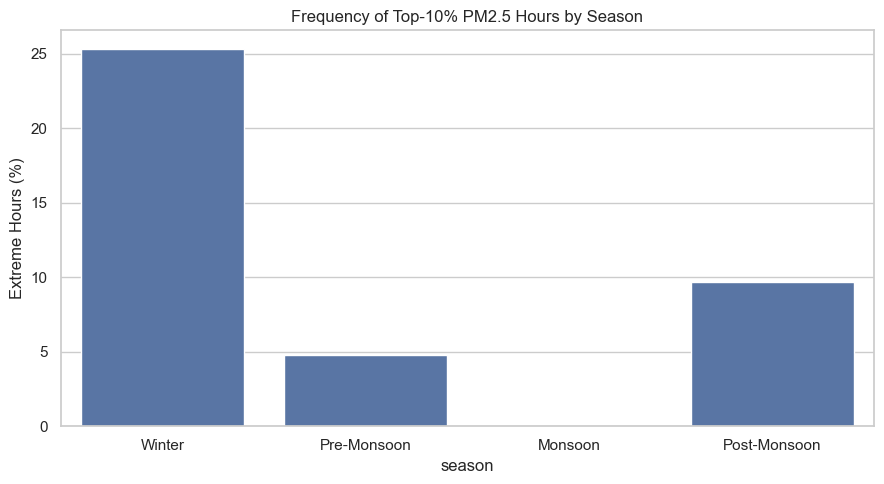

In [86]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=extreme_season.index,
    y=extreme_season.values
)

plt.title(
    'Frequency of Top-10% PM2.5 Hours by Season'
)

plt.ylabel('Extreme Hours (%)')

plt.tight_layout()
plt.show()

In [87]:
#Weather during normal vs extreme PM2.5
hourly['pm25_extreme_group'] = np.where(
    hourly['pm25_top10'] == 1,
    'Top 10%',
    'Other 90%'
)

In [88]:
extreme_weather_summary = (
    hourly
    .groupby('pm25_extreme_group')[
        [
            'temperature',
            'humidity',
            'wind_speed',
            'rain',
            'pressure',
            'dew_point'
        ]
    ]
    .median()
)

extreme_weather_summary

,temperature,humidity,wind_speed,rain,pressure,dew_point
pm25_extreme_group,,,,,,
Other 90%,19.4,77.0,3.6,0.0,871.2,12.5
Top 10%,10.8,78.0,4.3,0.0,871.6,6.6


## Dashain exploratory analysis
Dashain is the main festival in the country of Nepal. It is the time when most of the people leave Kathmandu valley to go to their hometown.

In [89]:
dashain_periods = {
    2022: (
        '2022-09-26',
        '2022-10-09 23:00:00'
    ),

    2023: (
        '2023-10-15',
        '2023-10-28 23:00:00'
    )
}

In [90]:
dashain_frames = []

for year, (start, end) in dashain_periods.items():

    temp = hourly.loc[
        start:end
    ].copy()

    temp['dashain_year'] = year

    dashain_frames.append(temp)

dashain = pd.concat(
    dashain_frames
)

In [91]:
dashain[
    [
        'pm25',
        'pm10',
        'temperature',
        'humidity',
        'wind_speed',
        'dashain_year'
    ]
].head()

,pm25,pm10,temperature,humidity,wind_speed,dashain_year
time,,,,,,
2022-09-26 00:00:00,32.5,46.4,18.1,100,4.5,2022
2022-09-26 01:00:00,29.4,42.0,18.7,99,4.8,2022
2022-09-26 02:00:00,28.3,40.5,20.5,92,3.1,2022
2022-09-26 03:00:00,28.4,40.6,22.0,85,1.5,2022
2022-09-26 04:00:00,20.1,28.8,23.5,79,3.3,2022


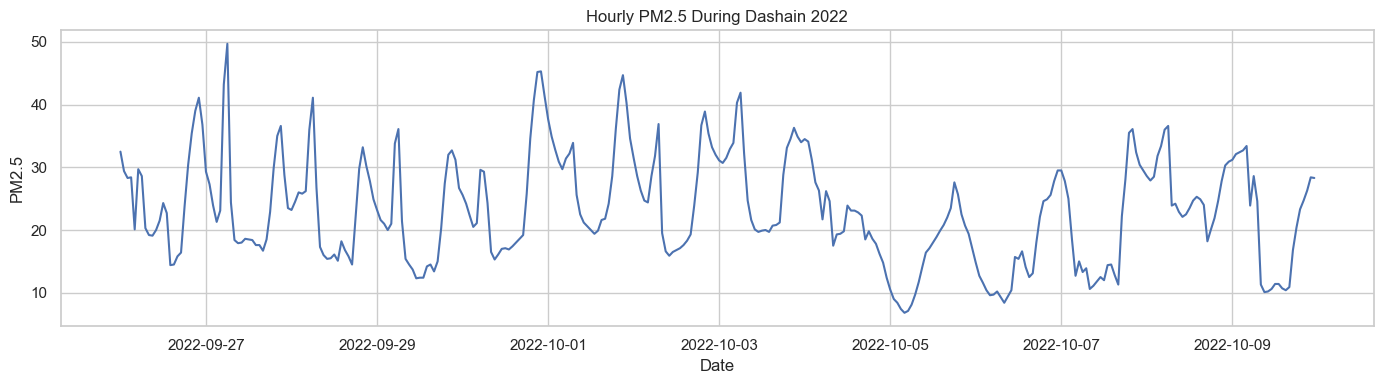

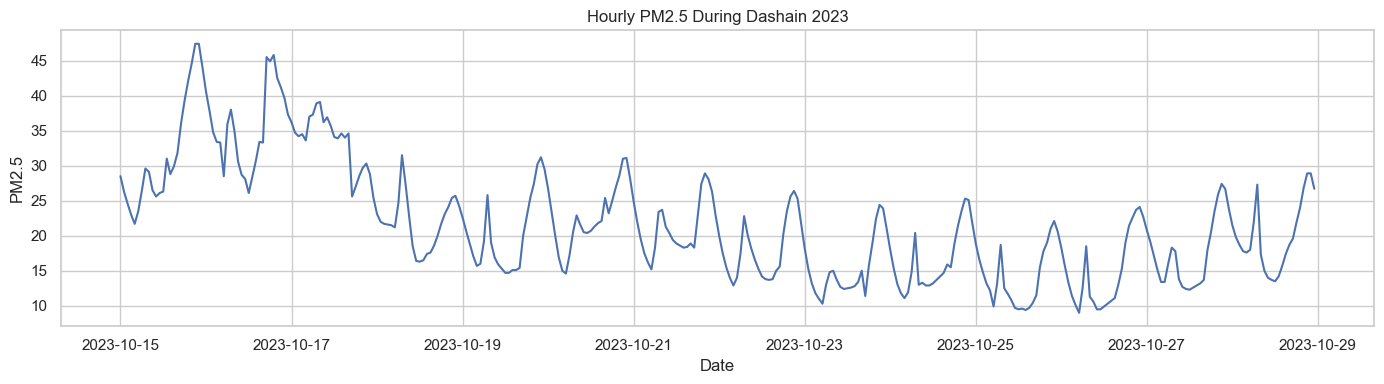

In [92]:
for year, (start, end) in dashain_periods.items():

    period = hourly.loc[start:end]

    plt.figure(figsize=(14, 4))

    plt.plot(
        period.index,
        period['pm25']
    )

    plt.title(
        f'Hourly PM2.5 During Dashain {year}'
    )

    plt.xlabel('Date')
    plt.ylabel('PM2.5')

    plt.tight_layout()
    plt.show()

In [93]:
dashain_summary = (
    dashain
    .groupby('dashain_year')['pm25']
    .agg([
        'count',
        'mean',
        'median',
        'std',
        'min',
        'max'
    ])
)

dashain_summary

,count,mean,median,std,min,max
dashain_year,,,,,,
2022,336,23.221429,22.4,8.478402,6.8,49.7
2023,336,21.599405,20.3,8.331218,9.0,47.4


In [94]:
#EDA findings table
eda_summary = {
    'hourly_observations':
        len(hourly),

    'daily_observations':
        len(daily),

    'mean_pm25':
        hourly['pm25'].mean(),

    'median_pm25':
        hourly['pm25'].median(),

    'max_pm25':
        hourly['pm25'].max(),

    'pm25_90th_percentile':
        hourly['pm25'].quantile(0.90),

    'pm25_95th_percentile':
        hourly['pm25'].quantile(0.95),

    'days_aqi_over_100':
        int(
            (daily['particle_aqi'] > 100)
            .sum()
        ),

    'days_aqi_over_150':
        int(
            (daily['particle_aqi'] > 150)
            .sum()
        ),

    'peak_mean_pm25_hour':
        int(
            hourly_pm25_pattern[
                'mean'
            ].idxmax()
        ),

    'peak_median_pm25_hour':
        int(
            hourly_pm25_pattern[
                'median'
            ].idxmax()
        ),

    'highest_mean_pm25_month':
        int(
            monthly_pm25[
                'mean'
            ].idxmax()
        ),

    'highest_median_pm25_season':
        str(
            season_pm25[
                'median'
            ].idxmax()
        )
}

eda_summary

{'hourly_observations': 23352,
 'daily_observations': 973,
 'mean_pm25': np.float64(35.04542223364166),
 'median_pm25': np.float64(29.0),
 'max_pm25': np.float64(170.4),
 'pm25_90th_percentile': np.float64(66.1),
 'pm25_95th_percentile': np.float64(83.6),
 'days_aqi_over_100': 397,
 'days_aqi_over_150': 145,
 'peak_mean_pm25_hour': 22,
 'peak_median_pm25_hour': 21,
 'highest_mean_pm25_month': 1,
 'highest_median_pm25_season': 'Winter'}

In [95]:
TABLES_DIR = (
    REPORTS_DIR /
    "tables" /
    "phase4_eda"
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [96]:
pollution_summary.to_csv(
    TABLES_DIR /
    "pollution_descriptive_statistics.csv"
)

hourly_pm25_pattern.to_csv(
    TABLES_DIR /
    "hourly_pm25_pattern.csv"
)

monthly_pm25.to_csv(
    TABLES_DIR /
    "monthly_pm25_pattern.csv"
)

season_pm25.to_csv(
    TABLES_DIR /
    "seasonal_pm25_pattern.csv"
)

pm25_weather_correlations.to_csv(
    TABLES_DIR /
    "pm25_weather_correlations.csv"
)

wind_pm25.to_csv(
    TABLES_DIR /
    "pm25_by_wind_sector.csv"
)

aqi_season_table.to_csv(
    TABLES_DIR /
    "aqi_categories_by_season.csv"
)

In [97]:
print("=" * 70)
print("PHASE 4 — EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 70)

print(
    f"\nHourly observations: "
    f"{len(hourly):,}"
)

print(
    f"Daily observations: "
    f"{len(daily):,}"
)

print(
    f"\nMean PM2.5: "
    f"{hourly['pm25'].mean():.2f}"
)

print(
    f"Median PM2.5: "
    f"{hourly['pm25'].median():.2f}"
)

print(
    f"Maximum PM2.5: "
    f"{hourly['pm25'].max():.2f}"
)

print(
    f"\nPeak mean PM2.5 hour: "
    f"{hourly_pm25_pattern['mean'].idxmax()}:00"
)

print(
    f"Peak median PM2.5 hour: "
    f"{hourly_pm25_pattern['median'].idxmax()}:00"
)

print(
    f"\nHighest mean PM2.5 month: "
    f"{monthly_pm25['mean'].idxmax()}"
)

print(
    f"Highest median PM2.5 season: "
    f"{season_pm25['median'].idxmax()}"
)

print(
    f"\nDays particulate AQI > 100: "
    f"{(daily['particle_aqi'] > 100).sum()}"
)

print(
    f"Days particulate AQI > 150: "
    f"{(daily['particle_aqi'] > 150).sum()}"
)

print("\nPM2.5-weather correlations:")
print(
    pm25_weather_correlations
    .sort_values(
        'Spearman'
    )
    .round(3)
)

print("\n" + "=" * 70)

PHASE 4 — EXPLORATORY DATA ANALYSIS SUMMARY

Hourly observations: 23,352
Daily observations: 973

Mean PM2.5: 35.05
Median PM2.5: 29.00
Maximum PM2.5: 170.40

Peak mean PM2.5 hour: 22:00
Peak median PM2.5 hour: 21:00

Highest mean PM2.5 month: 1
Highest median PM2.5 season: Winter

Days particulate AQI > 100: 397
Days particulate AQI > 150: 145

PM2.5-weather correlations:
             Pearson  Spearman
dew_point     -0.457    -0.503
temperature   -0.484    -0.496
rain          -0.158    -0.297
humidity      -0.054    -0.108
wind_speed     0.113     0.165
pressure       0.149     0.209



In [98]:
print(pollution_summary.round(2))

print("\nHourly PM2.5:")
print(hourly_pm25_pattern.round(2))

print("\nDay of week:")
print(dow_pm25.round(2))

print("\nWeekday vs weekend:")
print(weekday_weekend.round(2))

print("\nMonthly PM2.5:")
print(monthly_pm25.round(2))

print("\nSeasonal PM2.5:")
print(season_pm25.round(2))

print("\nAnnual PM2.5:")
print(annual_pm25.round(2))

print("\nAQI category percentages:")
print(aqi_percentages.round(2))

print("\nPearson pollutants:")
print(pearson_pollutants.round(3))

print("\nSpearman pollutants:")
print(spearman_pollutants.round(3))

print("\nPM2.5 vs weather:")
print(pm25_weather_correlations.round(3))

print("\nWind direction:")
print(wind_pm25.round(2))

print("\nRain:")
print(rain_pm25.round(2))

print("\nExtreme season:")
print(extreme_season.round(2))

print("\nEDA summary:")
print(eda_summary)


      count    mean  median     std   min     q1     q3     max  skewness  \
pm25  23352   35.05    29.0   23.25   0.2   18.8   44.6   170.4      1.53   
pm10  23352   48.61    42.3   28.37   0.3   27.4   64.5   221.2      1.05   
no2   23352   14.27    10.6   13.57   0.0    3.7   20.7   107.3      1.66   
so2   23352    6.77     5.6    4.77   0.0    3.7    8.3    37.5      2.05   
co    23352  669.84   523.0  469.38  59.0  333.0  839.0  3204.0      1.69   

      kurtosis  
pm25      2.82  
pm10      1.23  
no2       3.69  
so2       5.75  
co        3.05  

Hourly PM2.5:
       mean  median    std  count
hour                             
0     43.53    36.0  28.56    973
1     41.45    34.0  27.52    973
2     39.50    32.4  26.41    973
3     37.71    30.9  25.27    973
4     36.14    29.7  24.14    973
5     35.76    29.3  24.02    973
6     38.22    32.0  24.33    973
7     40.48    33.5  26.50    973
8     37.14    30.0  25.84    973
9     27.25    24.5  14.66    973
10    25.01 